# 🧪 Comprehensive Olfaction-Inspired NER Experiments - Marathi Dataset

**Goal**: Run 12 different NER experiments on Marathi (ai4bharat/naamapadam) dataset with comprehensive analysis

This notebook includes:
- ✅ 12 different experiment configurations
- ✅ Marathi NER dataset from HuggingFace (ai4bharat/naamapadam)
- ✅ Heatmap generation for receptor and glomeruli activations
- ✅ Comprehensive metrics (micro/macro averages, per-entity F1)
- ✅ Model saving and comparison
- ✅ Visualization and results export

**Estimated Runtime**: 6-10 hours on GPU (T4), longer on CPU (Marathi dataset is larger)

---

## 📋 Section 1: Setup & Environment

### 1.1 Check GPU Availability

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ No GPU - training will be slow!")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


### 1.2 Clone Repository

In [4]:
import getpass
import os

# Check if already in the repo directory
if not os.path.exists('src/train_marathi.py'):
    # Get your token securely (won't be visible in output)
    token = getpass.getpass('Enter your GitHub Personal Access Token: ')
    
    # Clone using token
    !git clone https://{token}@github.com/bhushan1729/olfaction-inspired-ner.git
    %cd olfaction-inspired-ner
else:
    print("✓ Already in repository directory")

✓ Already in repository directory


In [39]:
    # Get your token securely (won't be visible in output)
token = getpass.getpass('Enter your GitHub Personal Access Token: ')
    
    # Clone using token
!git clone https://{token}@github.com/bhushan1729/olfaction-inspired-ner.git
%cd olfaction-inspired-ner

Cloning into 'olfaction-inspired-ner'...
remote: Enumerating objects: 366, done.
remote: Counting objects: 100% (366/366), done.
remote: Compressing objects: 100% (253/253), done.
remote: Total 366 (delta 161), reused 301 (delta 99), pack-reused 0 (from 0)
Receiving objects: 100% (366/366), 24.25 MiB | 16.90 MiB/s, done.
Resolving deltas: 100% (161/161), done.
/content/olfaction-inspired-ner/olfaction-inspired-ner/olfaction-inspired-ner/olfaction-inspired-ner/olfaction-inspired-ner


### 1.3 Install Dependencies

In [5]:
!pip install -q torch numpy scikit-learn seqeval matplotlib seaborn pandas tqdm tensorboard pyyaml requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


### 1.4 Download GloVe Embeddings

In [6]:
import os

if not os.path.exists('./data/glove.6B.300d.txt'):
    print("Downloading GloVe embeddings (takes ~5 min)...")
    !mkdir -p data
    !wget -q http://nlp.stanford.edu/data/glove.6B.zip -O data/glove.6B.zip
    !unzip -q data/glove.6B.zip -d data/
    !rm data/glove.6B.zip
    print("✓ GloVe downloaded")
else:
    print("✓ GloVe already exists")

✓ GloVe downloaded


### 1.5 Configure Python Path

In [17]:
import sys
import os

# Get the current working directory and add to path
project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"✓ Path configured: {project_root}")

✓ Path configured: /content/olfaction-inspired-ner/olfaction-inspired-ner/olfaction-inspired-ner/olfaction-inspired-ner


### 1.6 Create Results Directories

In [18]:
# Create directories for results and visualizations
!mkdir -p results visualizations

print("✓ Directories created:")
print("  - results/")
print("  - visualizations/")

✓ Directories created:
  - results/
  - visualizations/


### Mount Google Drive

In [ ]:
# Mount Google Drive with error handling
from google.colab import drive
import os

try:
    # Try force remount if already mounted
    drive.mount('/content/drive', force_remount=True)
    print("✓ Google Drive mounted successfully!")
    
    # Create project directory in Google Drive
    drive_project_dir = '/content/drive/MyDrive/olfaction-ner-experiments'
    os.makedirs(drive_project_dir, exist_ok=True)
    os.makedirs(f'{drive_project_dir}/results', exist_ok=True)
    os.makedirs(f'{drive_project_dir}/visualizations', exist_ok=True)
    
    print(f"✓ Results will be saved to: {drive_project_dir}")
    
except Exception as e:
    print(f"❌ Drive mount failed: {e}")
    print("⚠️  Continuing without Drive mount")
    print("ℹ️  You can download results at the end using the zip file")
    drive_project_dir = None

### Auto-Save Function

In [19]:
import shutil
import json
from pathlib import Path

def save_to_drive(experiment_name):
    """
    Copy experiment results to Google Drive.
    
    Args:
        experiment_name: Name of the experiment (e.g., 'activation_gelu')
    """
    drive_dir = '/content/drive/MyDrive/olfaction-ner-experiments'
    
    # Source directories
    local_results = f'results/{experiment_name}'
    local_viz = f'visualizations/{experiment_name}'
    
    # Destination directories
    drive_results = f'{drive_dir}/results/{experiment_name}'
    drive_viz = f'{drive_dir}/visualizations/{experiment_name}'
    
    # Copy results
    if os.path.exists(local_results):
        os.makedirs(drive_results, exist_ok=True)
        
        # Copy model files
        for file in ['best_model.pt', 'results.json', 'metrics.json']:
            src = f'{local_results}/{file}'
            if os.path.exists(src):
                shutil.copy2(src, f'{drive_results}/{file}')
                print(f"  ✓ Saved {file} to Drive")
    
    # Copy visualizations
    if os.path.exists(local_viz):
        os.makedirs(drive_viz, exist_ok=True)
        
        for file in os.listdir(local_viz):
            src = f'{local_viz}/{file}'
            shutil.copy2(src, f'{drive_viz}/{file}')
            print(f"  ✓ Saved {file} to Drive")
    
    print(f"✓ Experiment '{experiment_name}' saved to Google Drive!")

# Test the function
print("✓ Auto-save function ready!")

✓ Auto-save function ready!


---
## 🏋️ Section 2: Train 12 Experiments

Each experiment trains a different model configuration and saves:
- Best model checkpoint (`best_model.pt`)
- Training results (`results.json`)
- Training metrics (`metrics.json`)

### Experiment 1: GELU Activation
**Hypothesis**: Biologically-plausible GELU activation improves receptor specialization

### Experiment 2: Mish Activation
**Hypothesis**: Mish activation with smooth gradients helps training

### Experiment 3: More Receptors (256)
**Hypothesis**: More receptors increase model capacity and specialization

### Experiment 4: More Glomeruli

### Experiment 5: GELU + More Receptors
**Hypothesis**: Combining best activation (GELU) with more capacity (256 receptors)

### Experiment 6: Baseline BiLSTM-CRF
**Baseline**: Standard BiLSTM-CRF without olfactory components

In [ ]:
experiments = ['activation_gelu', 'activation_mish', 'more_glomeruli', 'more_receptors'
               'gelu_more_receptors', 'baseline']

for exp in experiments:
    !python src/train_marathi.py \
      --config config/marathi_selected_experiments.yaml \
      --experiment {exp} \
      --save_dir results_marathi/{exp}
    save_to_drive(exp)

Using device: cuda

Loading data...
Loading WikiANN dataset from HuggingFace...
Dataset: wikiann
Configuration: mr (Marathi)
Generating validation split: 100% 1000/1000 [00:00<00:00, 134717.80 examples/s]
Generating test split: 100% 1000/1000 [00:00<00:00, 213744.28 examples/s]
Generating train split: 100% 5000/5000 [00:00<00:00, 345967.63 examples/s]

Data splits available: ['validation', 'test', 'train']
Number of labels: 7
Label names: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']

Data splits:
  Train: 5000 sentences
  Valid: 1000 sentences
  Test: 1000 sentences

Building vocabularies...
Vocabulary size: 3208
Number of labels: 7
Labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']

Creating olfactory model...
Total parameters: 1,602,598
Trainable parameters: 1,602,598

Starting training...

Epoch 1/20
Training: 100% 157/157 [00:04<00:00, 35.47it/s, loss=2.9576, task=2.9568] 

Evaluating on validation set...
Evaluating: 100% 32/32 [00:00<00:00, 90.54it/

In [67]:
experiments = [ 'more_receptors']

for exp in experiments:
    !python src/train_marathi.py \
      --config config/marathi_selected_experiments.yaml \
      --experiment {exp} \
      --save_dir results_marathi/{exp}
    save_to_drive(exp)

Traceback (most recent call last):
  File "/content/olfaction-inspired-ner/olfaction-inspired-ner/olfaction-inspired-ner/olfaction-inspired-ner/olfaction-inspired-ner/src/train_marathi.py", line 257, in <module>
    main()
  File "/content/olfaction-inspired-ner/olfaction-inspired-ner/olfaction-inspired-ner/olfaction-inspired-ner/olfaction-inspired-ner/src/train_marathi.py", line 248, in main
    raise ValueError(f"Experiment '{args.experiment}' not found in config file")
ValueError: Experiment 'more_receptors' not found in config file
✓ Experiment 'more_receptors' saved to Google Drive!


---
## 🔥 Section 3: Generate Heatmaps

Generate receptor and glomeruli activation heatmaps for all olfactory experiments.

### 3.1 Load Data and Setup


In [41]:
import torch
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from src.model.olfactory_ner import create_olfactory_ner
from src.analysis.visualize import analyze_receptor_activations

from src.data.dataset_marathi import prepare_marathi_data
# Load test data
print("Loading WikiANN Marathi dataset for analysis...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loader, valid_loader, test_loader, vocab_info = prepare_marathi_data(
    cache_dir='./data/wikiann',
    batch_size=32,
    min_freq=2
)

print(f"✓ Data loaded (Test: {len(test_loader.dataset)} samples)")
print(f"✓ Device: {device}")

Loading WikiANN Marathi dataset for analysis...
Loading WikiANN dataset from HuggingFace...
Dataset: wikiann
Configuration: mr (Marathi)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(



Data splits available: ['validation', 'test', 'train']
Number of labels: 7
Label names: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']

Data splits:
  Train: 5000 sentences
  Valid: 1000 sentences
  Test: 1000 sentences

Building vocabularies...
Vocabulary size: 3208
Number of labels: 7
Labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']
✓ Data loaded (Test: 1000 samples)
✓ Device: cuda


### 3.2 Generate Heatmaps for All Olfactory Experiments

In [27]:
# List of olfactory experiments (experiments that have receptor layers)
olfactory_experiments = [
    'activation_gelu',
    'activation_swish',
    'activation_mish',
    'more_receptors',
    'more_glomeruli',
    'fewer_receptors',
    'strong_diversity',
    'very_strong_diversity',
    'gelu_more_receptors',
    'minimal_gelu',
    'olfactory_full',
    'olfactory_no_glomeruli'
]

print("=" * 80)
print("GENERATING HEATMAPS FOR OLFACTORY EXPERIMENTS")
print("=" * 80)

heatmap_results = {}

for exp_name in olfactory_experiments:
    model_path = f'results/{exp_name}/best_model.pt'
    results_path = f'results/{exp_name}/results.json'
    
    if not os.path.exists(model_path):
        print(f"⚠️  Skipping {exp_name} - model not found")
        continue
    
    if not os.path.exists(results_path):
        print(f"⚠️  Skipping {exp_name} - results not found")
        continue
    
    print(f"\n{'='*80}")
    print(f"Processing: {exp_name}")
    print(f"{'='*80}")
    
    # Load config
    with open(results_path, 'r') as f:
        exp_results = json.load(f)
    
    config = exp_results.get('config', {})
    
    # Load model
    vocab_size = len(vocab_info['word2idx'])
    num_tags = len(vocab_info['label2idx'])
    
    try:
        model = create_olfactory_ner(vocab_size, num_tags, config)
        checkpoint = torch.load(model_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        model = model.to(device)
        model.eval()
        
        # Create save directory for this experiment
        save_dir = f'visualizations/{exp_name}'
        os.makedirs(save_dir, exist_ok=True)
        
        # Analyze receptors
        print(f"Analyzing receptor activations...")
        results = analyze_receptor_activations(
            model, 
            test_loader, 
            vocab_info, 
            device, 
            save_dir=save_dir
        )
        
        heatmap_results[exp_name] = {
            'save_dir': save_dir,
            'results': results
        }
        
        print(f"✓ Heatmaps saved to {save_dir}")
        
    except Exception as e:
        print(f"❌ Error processing {exp_name}: {e}")
        continue

print("\n" + "="*80)
print("HEATMAP GENERATION COMPLETE!")
print("="*80)
print(f"Generated heatmaps for {len(heatmap_results)} experiments")

GENERATING HEATMAPS FOR OLFACTORY EXPERIMENTS
⚠️  Skipping activation_gelu - model not found
⚠️  Skipping activation_swish - model not found
⚠️  Skipping activation_mish - model not found

Processing: more_receptors
❌ Error processing more_receptors: Error(s) in loading state_dict for OlfactoryNER:
	size mismatch for embedding.weight: copying a param with shape torch.Size([3208, 300]) from checkpoint, the shape in current model is torch.Size([11984, 300]).
	size mismatch for hidden2tag.weight: copying a param with shape torch.Size([7, 512]) from checkpoint, the shape in current model is torch.Size([8, 512]).
	size mismatch for hidden2tag.bias: copying a param with shape torch.Size([7]) from checkpoint, the shape in current model is torch.Size([8]).
	size mismatch for crf.transitions: copying a param with shape torch.Size([7, 7]) from checkpoint, the shape in current model is torch.Size([8, 8]).
	size mismatch for crf.start_transitions: copying a param with shape torch.Size([7]) from ch

# For Marathi

In [42]:
# List of olfactory experiments (only the ones you're running)
olfactory_experiments = [
    'activation_gelu',
    'activation_mish',
    'more_glomeruli',
    'gelu_more_receptors'
    # Note: 'baseline' is excluded - it has no olfactory layers (no receptors/glomeruli)
]

print("=" * 80)
print("GENERATING HEATMAPS FOR OLFACTORY EXPERIMENTS")
print("=" * 80)

heatmap_results = {}

for exp_name in olfactory_experiments:
    model_path = f'results_marathi/{exp_name}/best_model.pt'  # Changed from 'results/'
    results_path = f'results_marathi/{exp_name}/results.json'  # Changed from 'results/'
    
    if not os.path.exists(model_path):
        print(f"⚠️  Skipping {exp_name} - model not found")
        continue
    
    if not os.path.exists(results_path):
        print(f"⚠️  Skipping {exp_name} - results not found")
        continue
    
    print(f"\n{'='*80}")
    print(f"Processing: {exp_name}")
    print(f"{'='*80}")
    
    # Load config
    with open(results_path, 'r') as f:
        exp_results = json.load(f)
    
    config = exp_results.get('config', {})
    
    # Load model
    vocab_size = len(vocab_info['word2idx'])
    num_tags = len(vocab_info['label2idx'])
    
    try:
        model = create_olfactory_ner(vocab_size, num_tags, config)
        checkpoint = torch.load(model_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        model = model.to(device)
        model.eval()
        
        # Create save directory for this experiment
        save_dir = f'visualizations_marathi/{exp_name}'  # Changed from 'visualizations/'
        os.makedirs(save_dir, exist_ok=True)
        
        # Analyze receptors
        print(f"Analyzing receptor activations...")
        results = analyze_receptor_activations(
            model, 
            test_loader, 
            vocab_info, 
            device, 
            save_dir=save_dir
        )
        
        heatmap_results[exp_name] = {
            'save_dir': save_dir,
            'results': results
        }
        
        print(f"✓ Heatmaps saved to {save_dir}")
        
    except Exception as e:
        print(f"❌ Error processing {exp_name}: {e}")
        continue

print("\n" + "="*80)
print("HEATMAP GENERATION COMPLETE!")
print("="*80)
print(f"Generated heatmaps for {len(heatmap_results)} experiments")

GENERATING HEATMAPS FOR OLFACTORY EXPERIMENTS

Processing: activation_gelu
Analyzing receptor activations...
Creating receptor activation heatmap...
Finding top activating tokens per receptor...

Top 5 receptors and their top tokens:

Receptor 0:
  सिंग: 5.612
  सिंग: 5.612
  सिंग: 5.612
  सम्राट: 5.338
  सम्राट: 5.338

Receptor 1:
  ट्रेक: 5.469
  ट्रेक: 5.469
  ट्रेक: 5.469
  ट्रेक: 5.469
  ट्रेक: 5.469

Receptor 2:
  पुनर्निर्देशन: 4.159
  पुनर्निर्देशन: 4.159
  पुनर्निर्देशन: 4.159
  पुनर्निर्देशन: 4.159
  पुनर्निर्देशन: 4.159

Receptor 3:
  इंडिया: 5.933
  इंडिया: 5.933
  इंडिया: 5.933
  इंडिया: 5.933
  इंडिया: 5.933

Receptor 4:
  <UNK>: 7.497
  <UNK>: 7.497
  <UNK>: 7.497
  <UNK>: 7.497
  <UNK>: 7.497

Creating t-SNE visualization...

Computing receptor specialization metrics...
Receptor activation sparsity: 31.50%
Average activation (when active): 1.540

✓ Analysis complete! Results saved to visualizations_marathi/activation_gelu
✓ Heatmaps saved to visualizations_marathi/activ

### 3.3 Display Heatmaps Grid


RECEPTOR ACTIVATION HEATMAPS

ACTIVATION_GELU


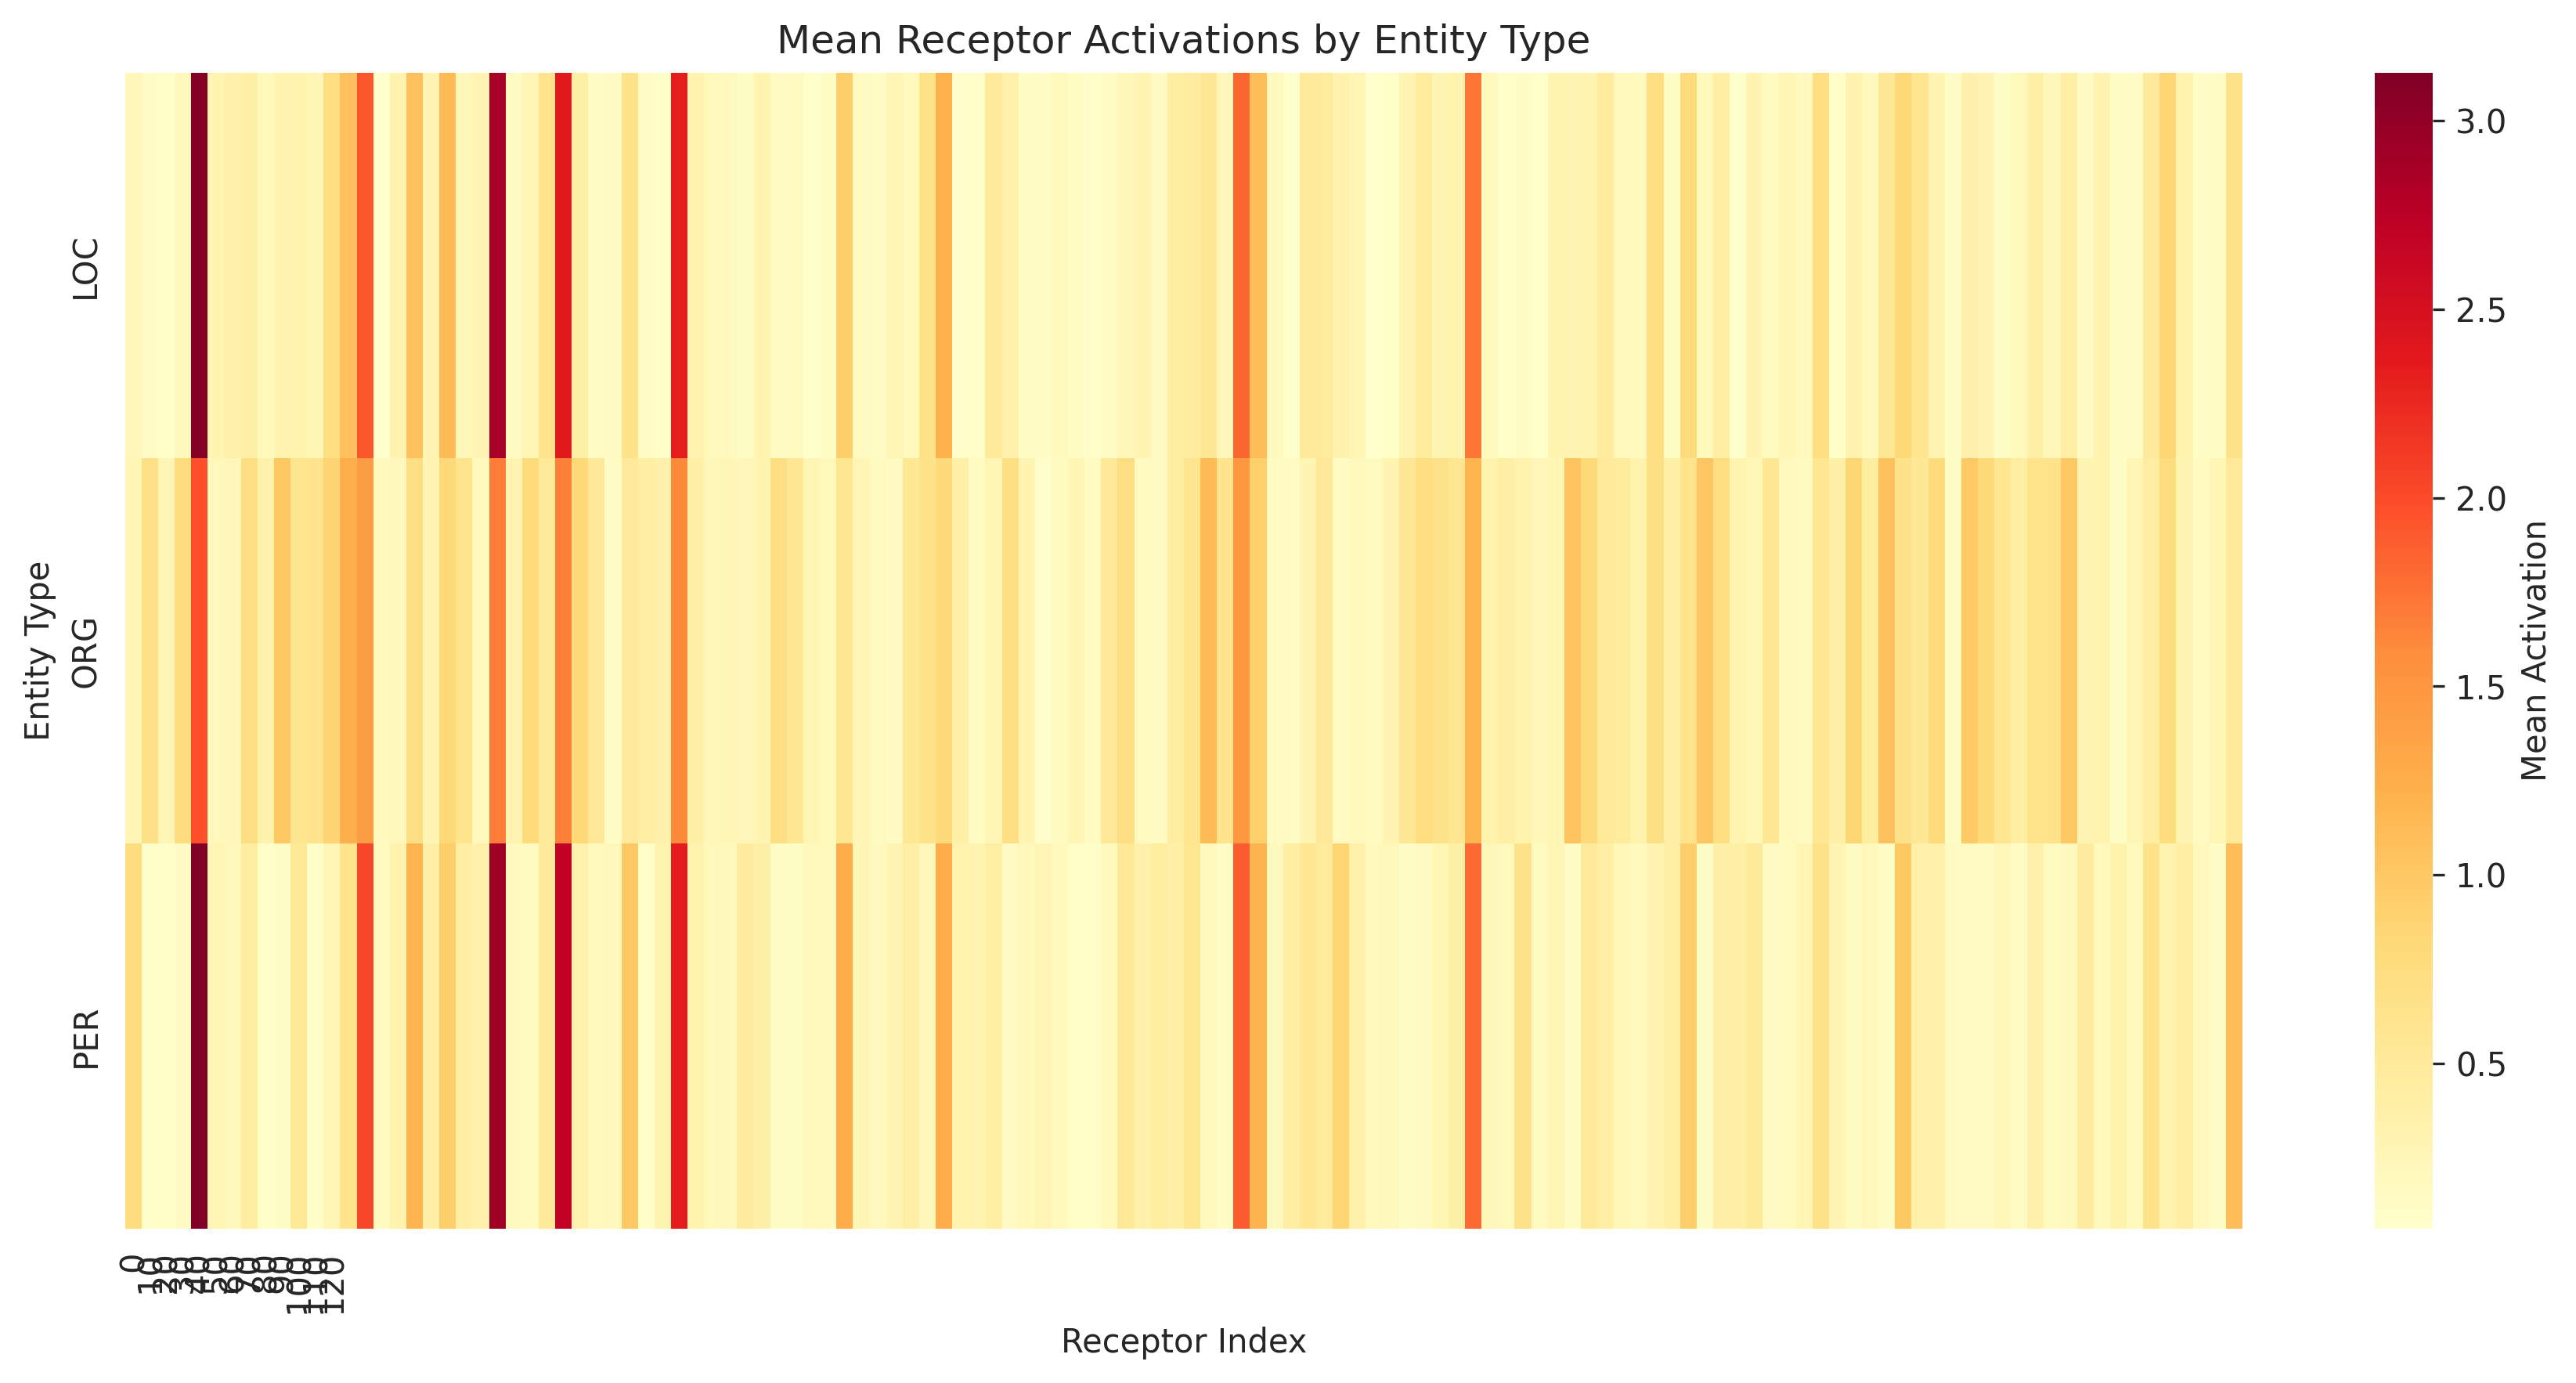


ACTIVATION_MISH


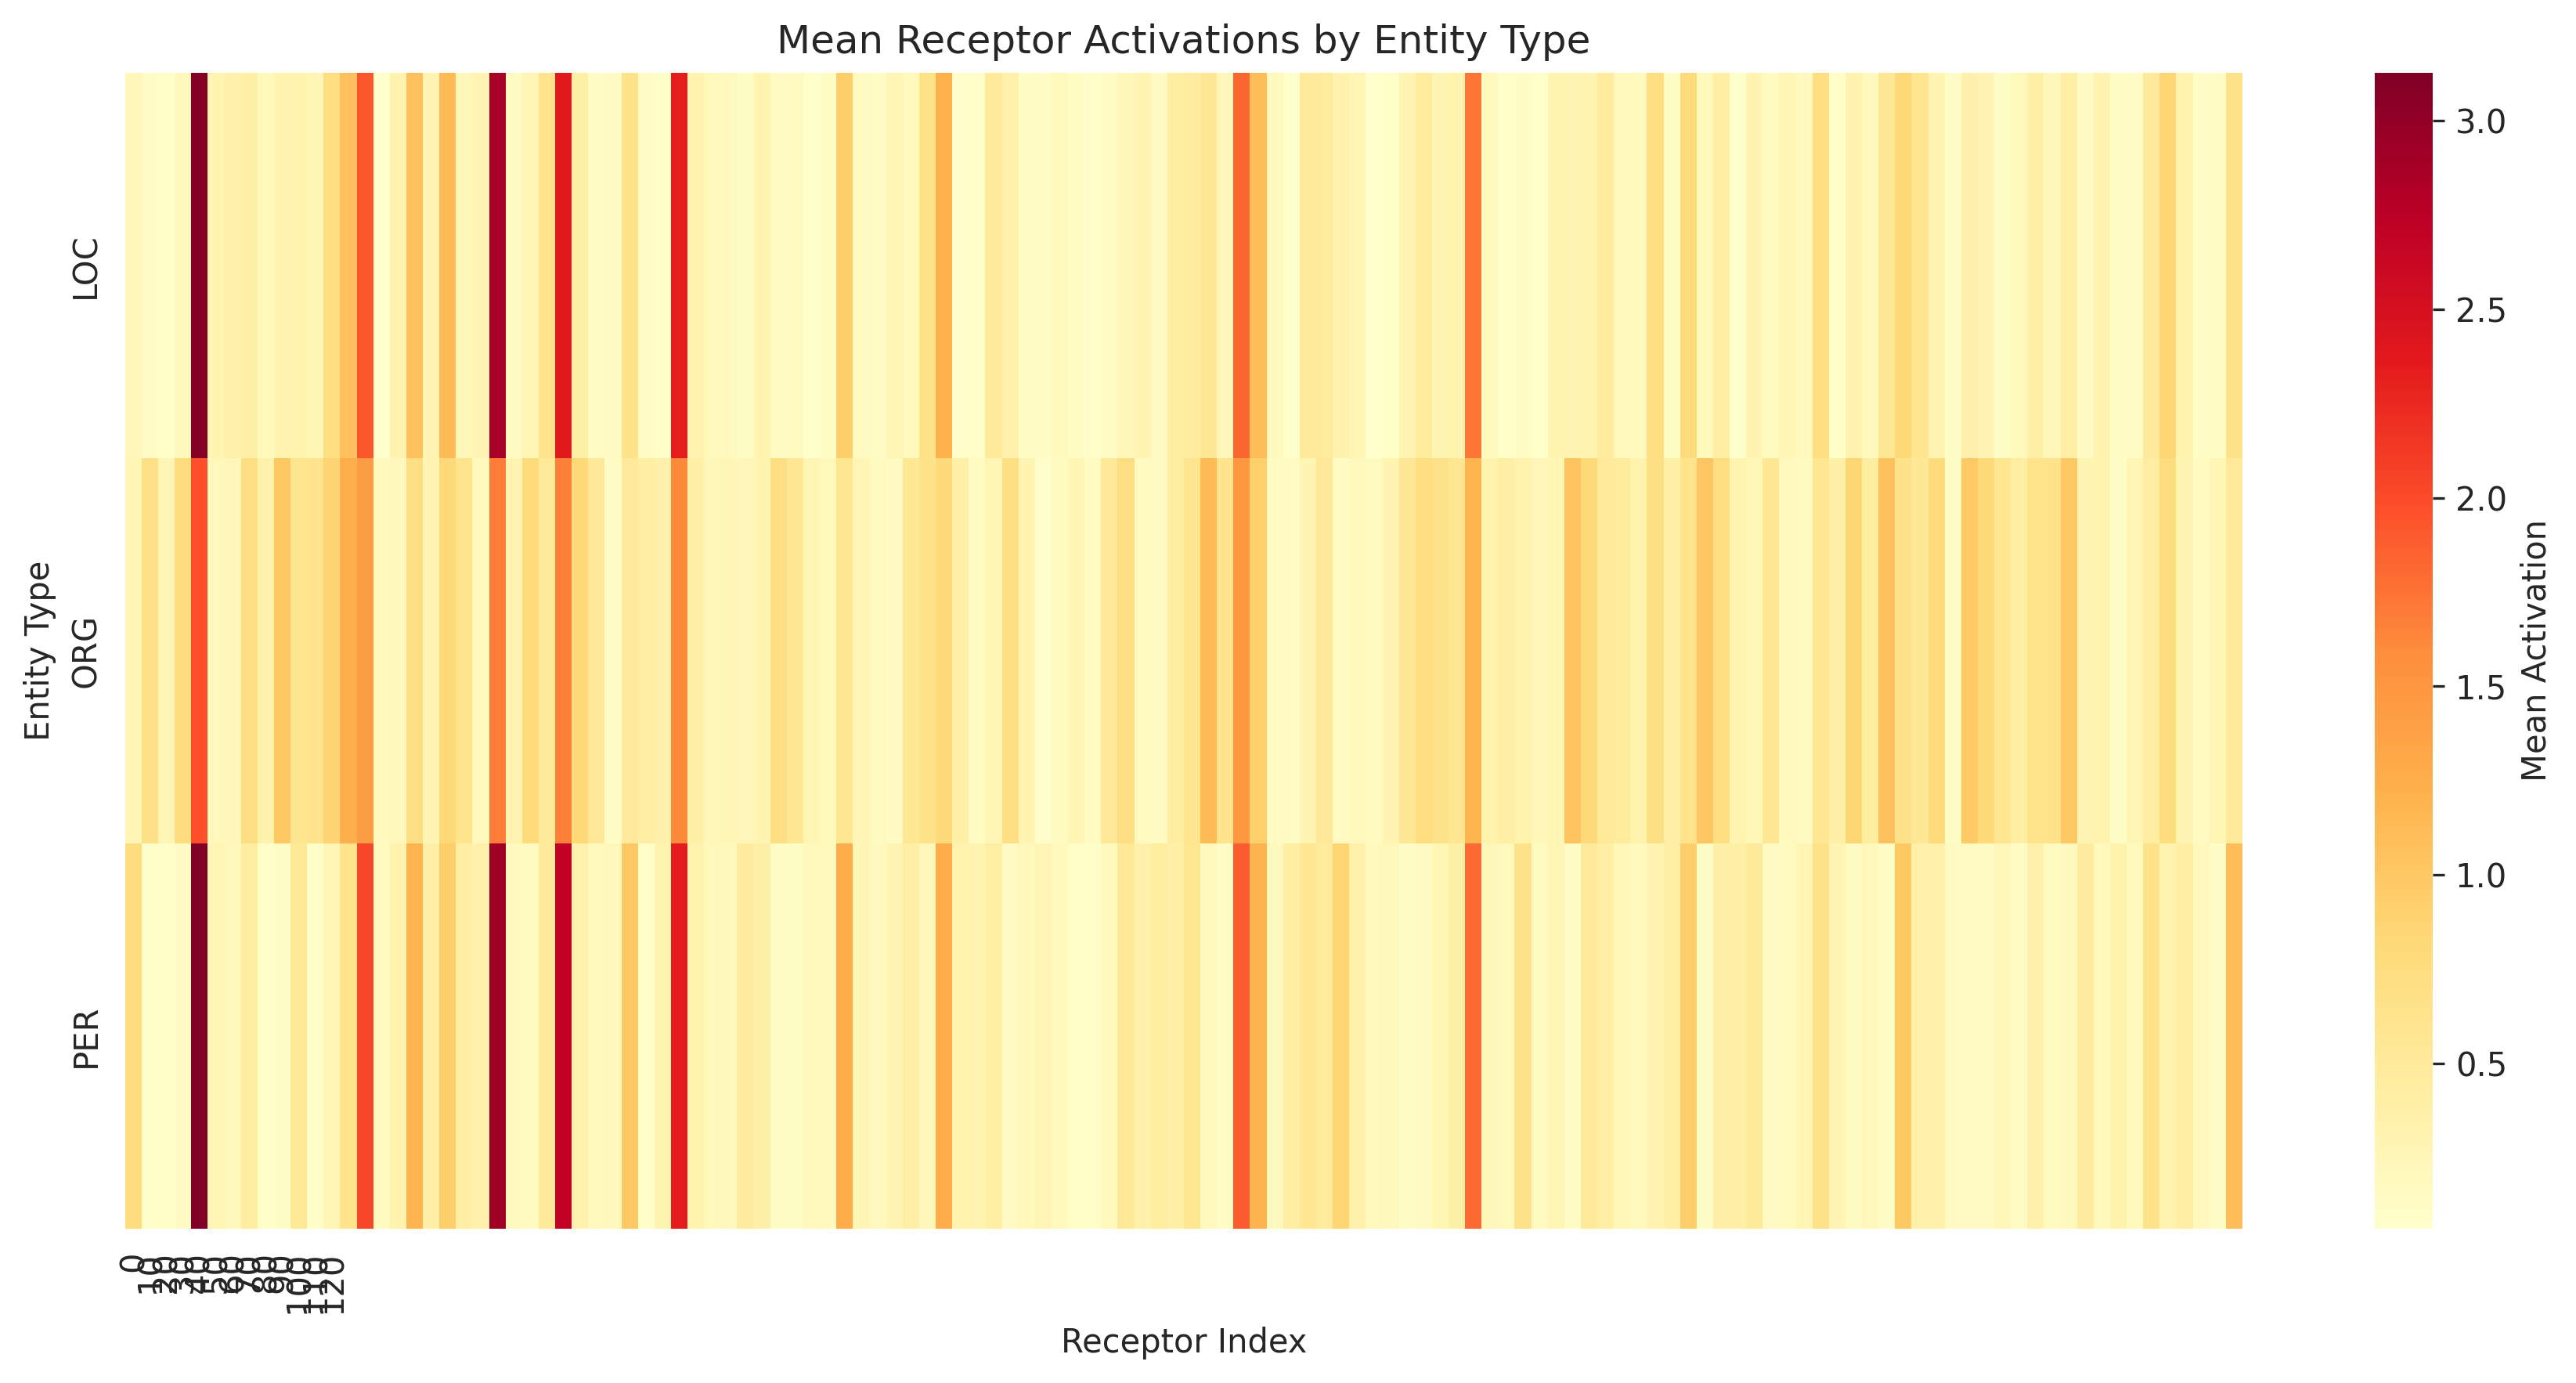


MORE_GLOMERULI


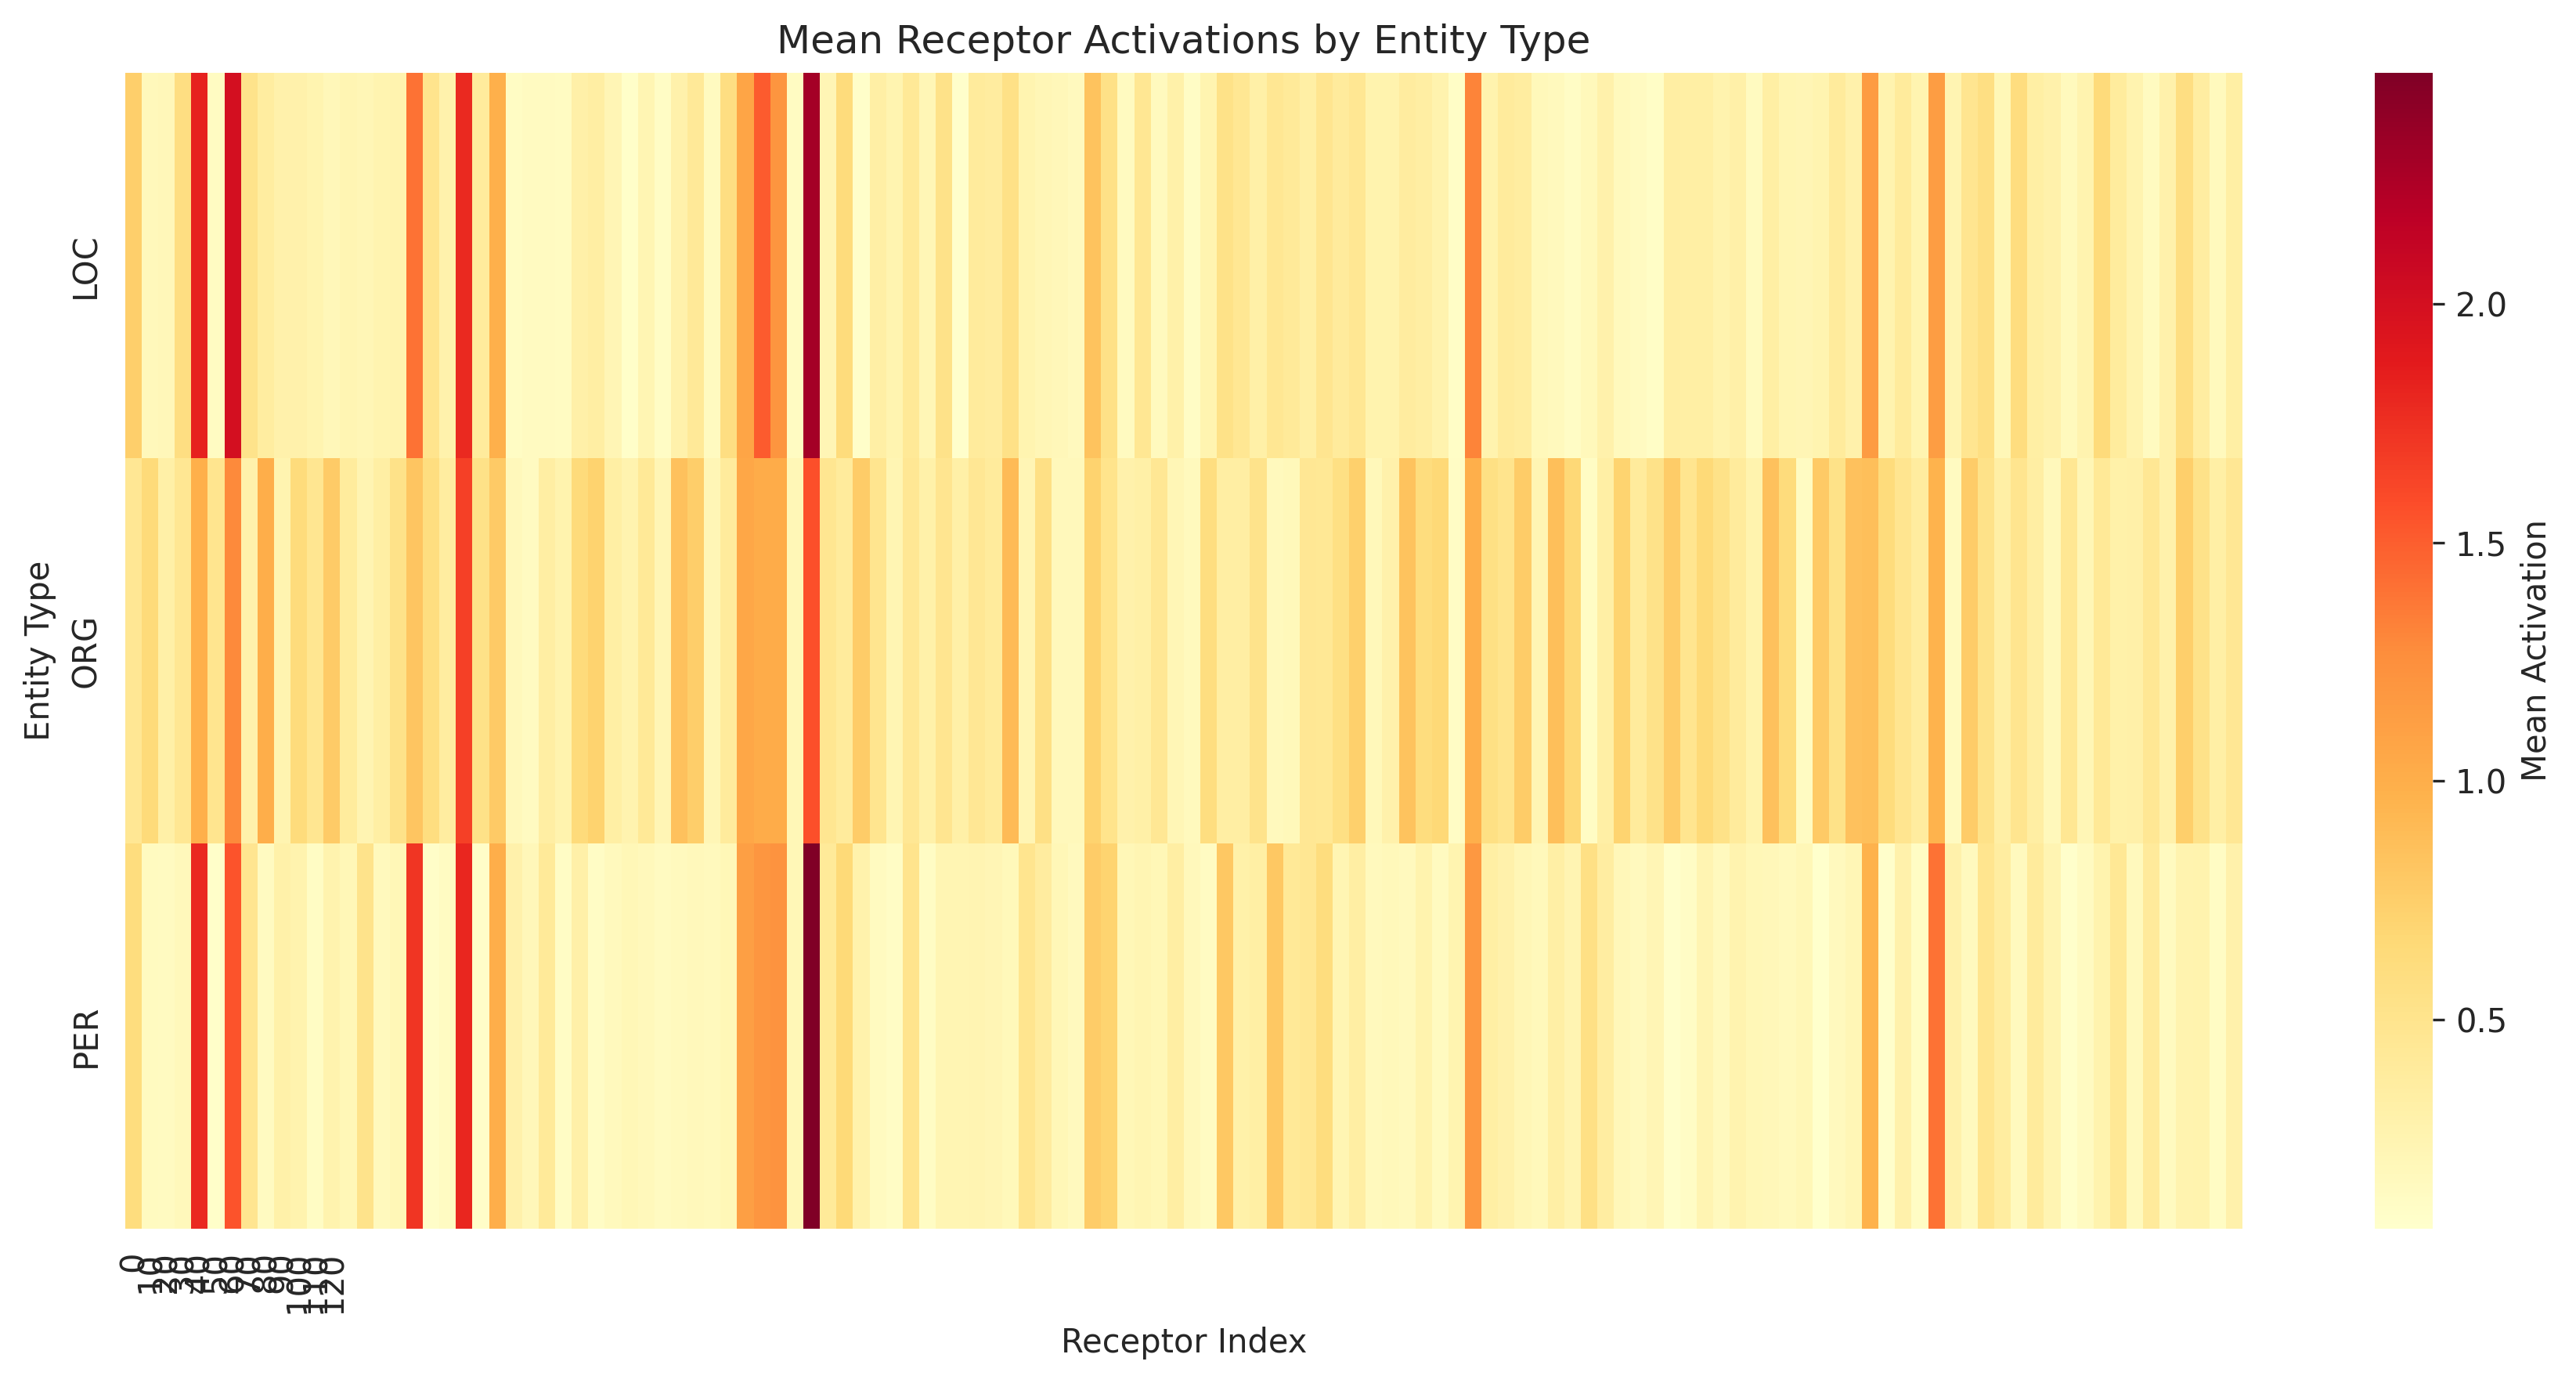


GELU_MORE_RECEPTORS


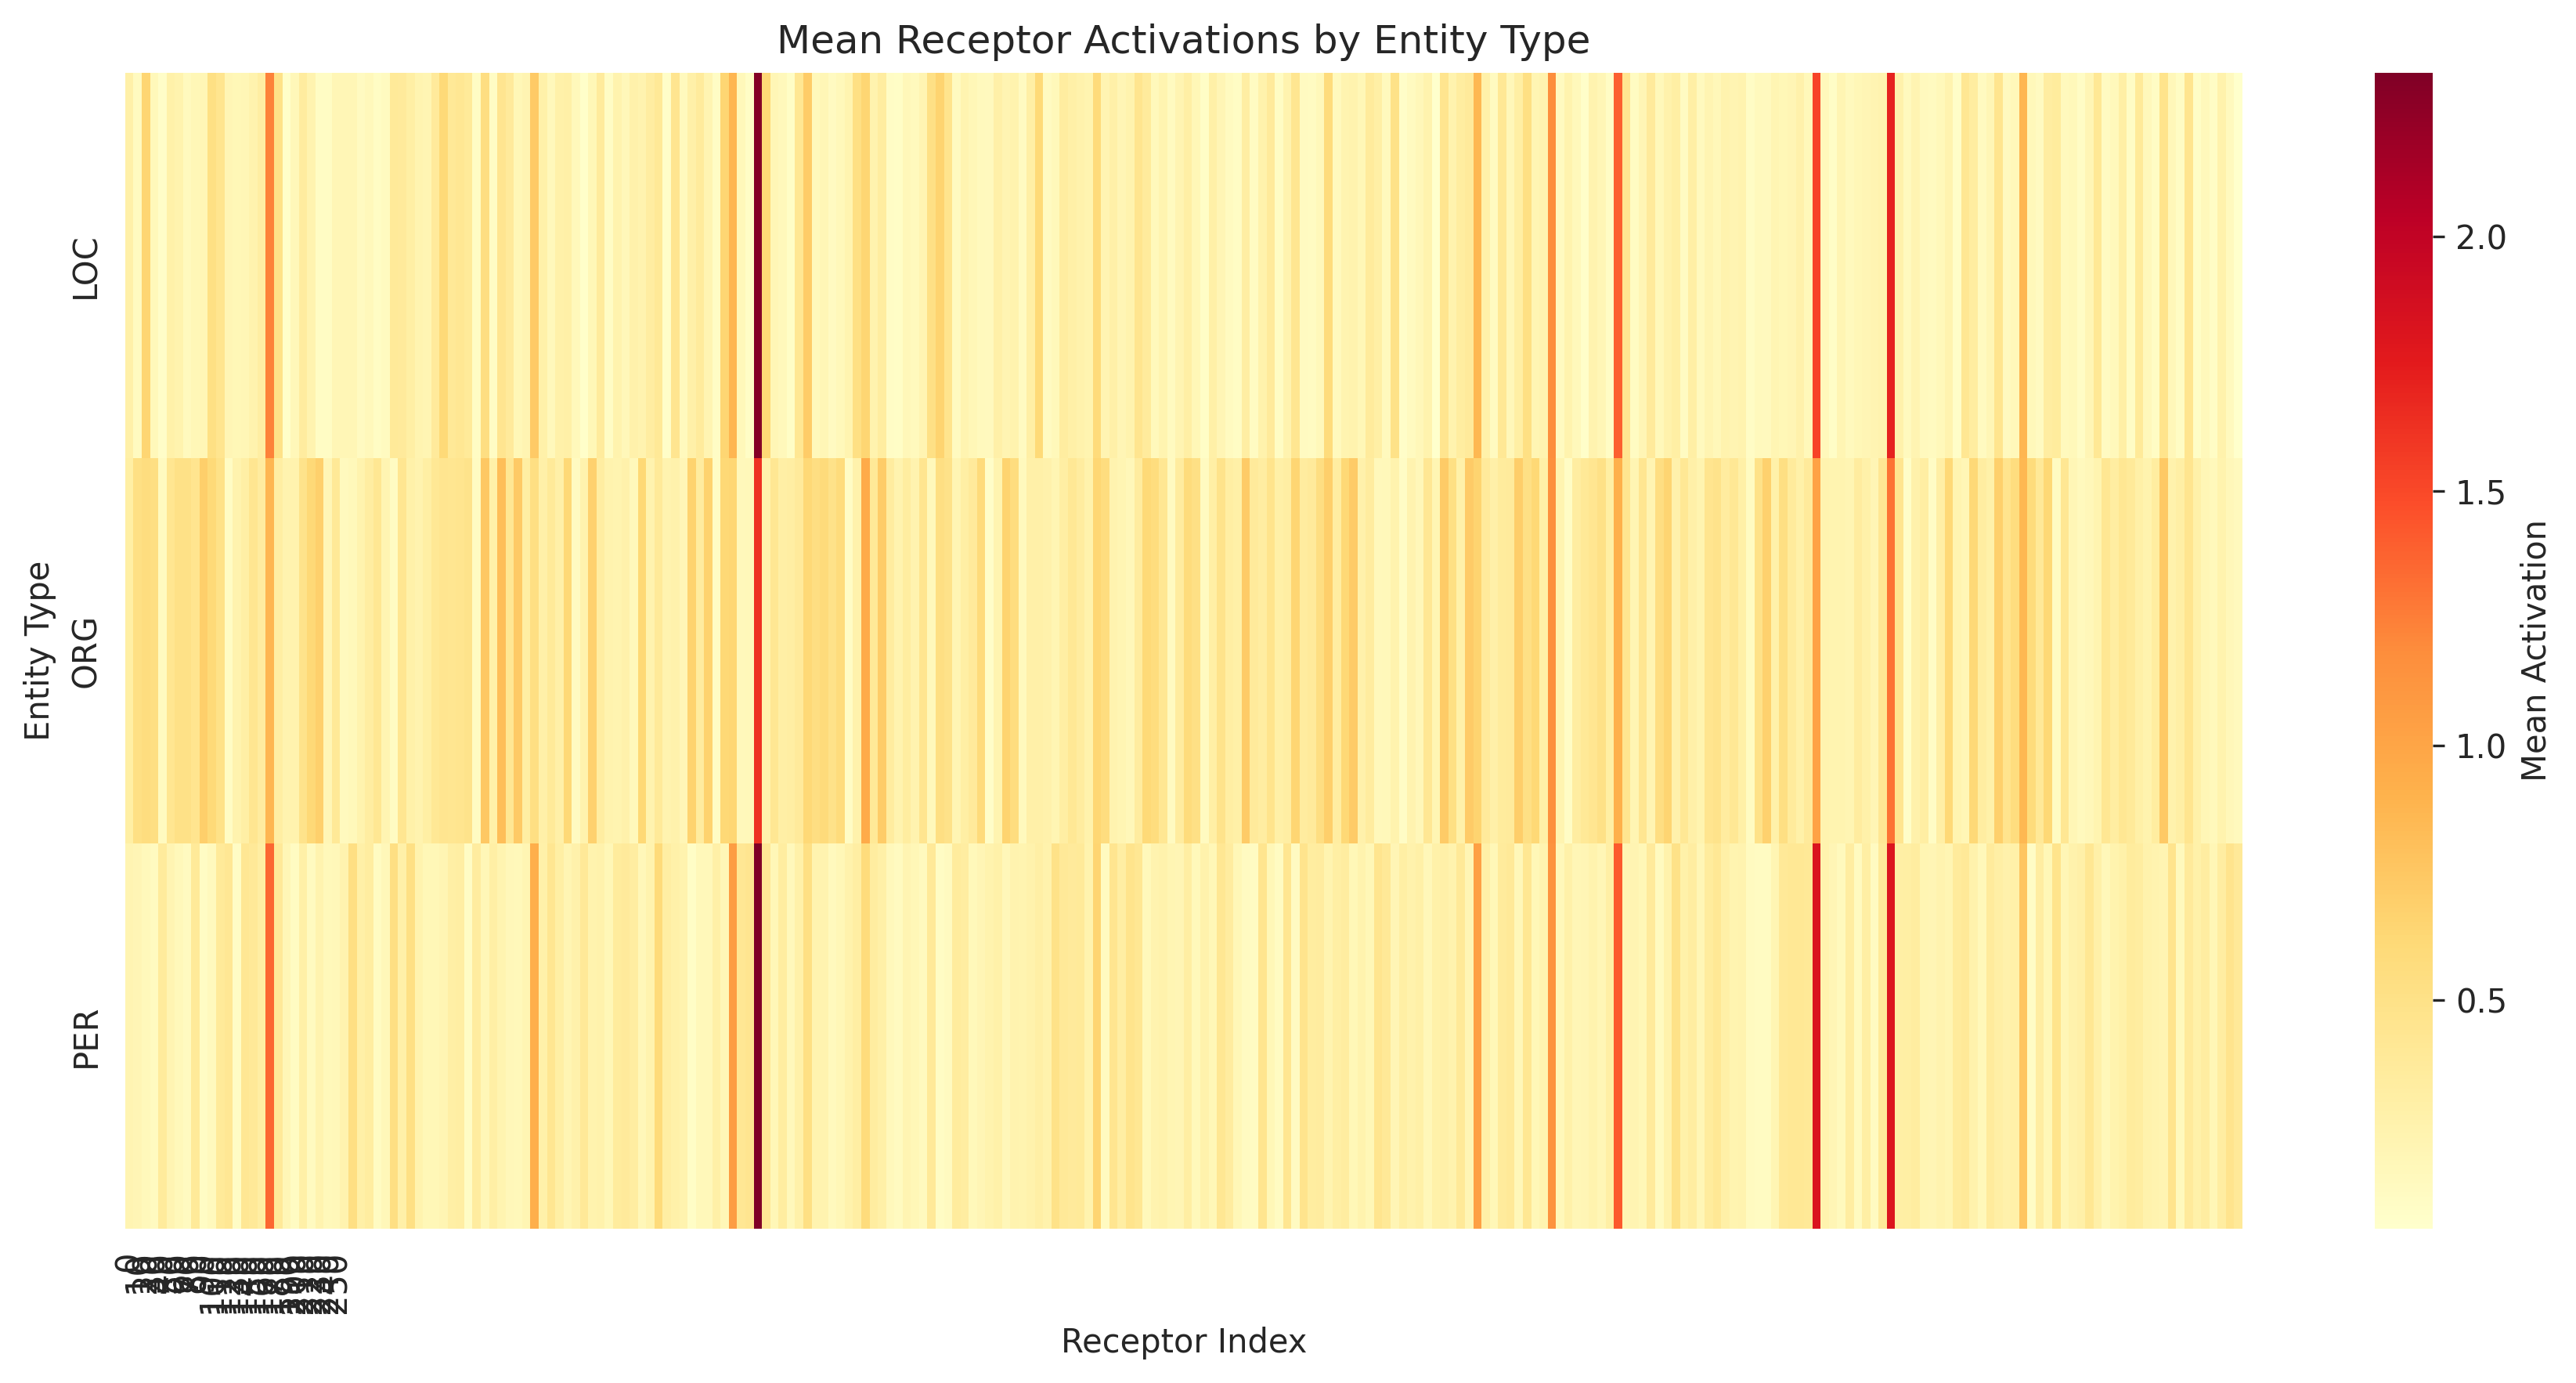


t-SNE VISUALIZATIONS

ACTIVATION_GELU


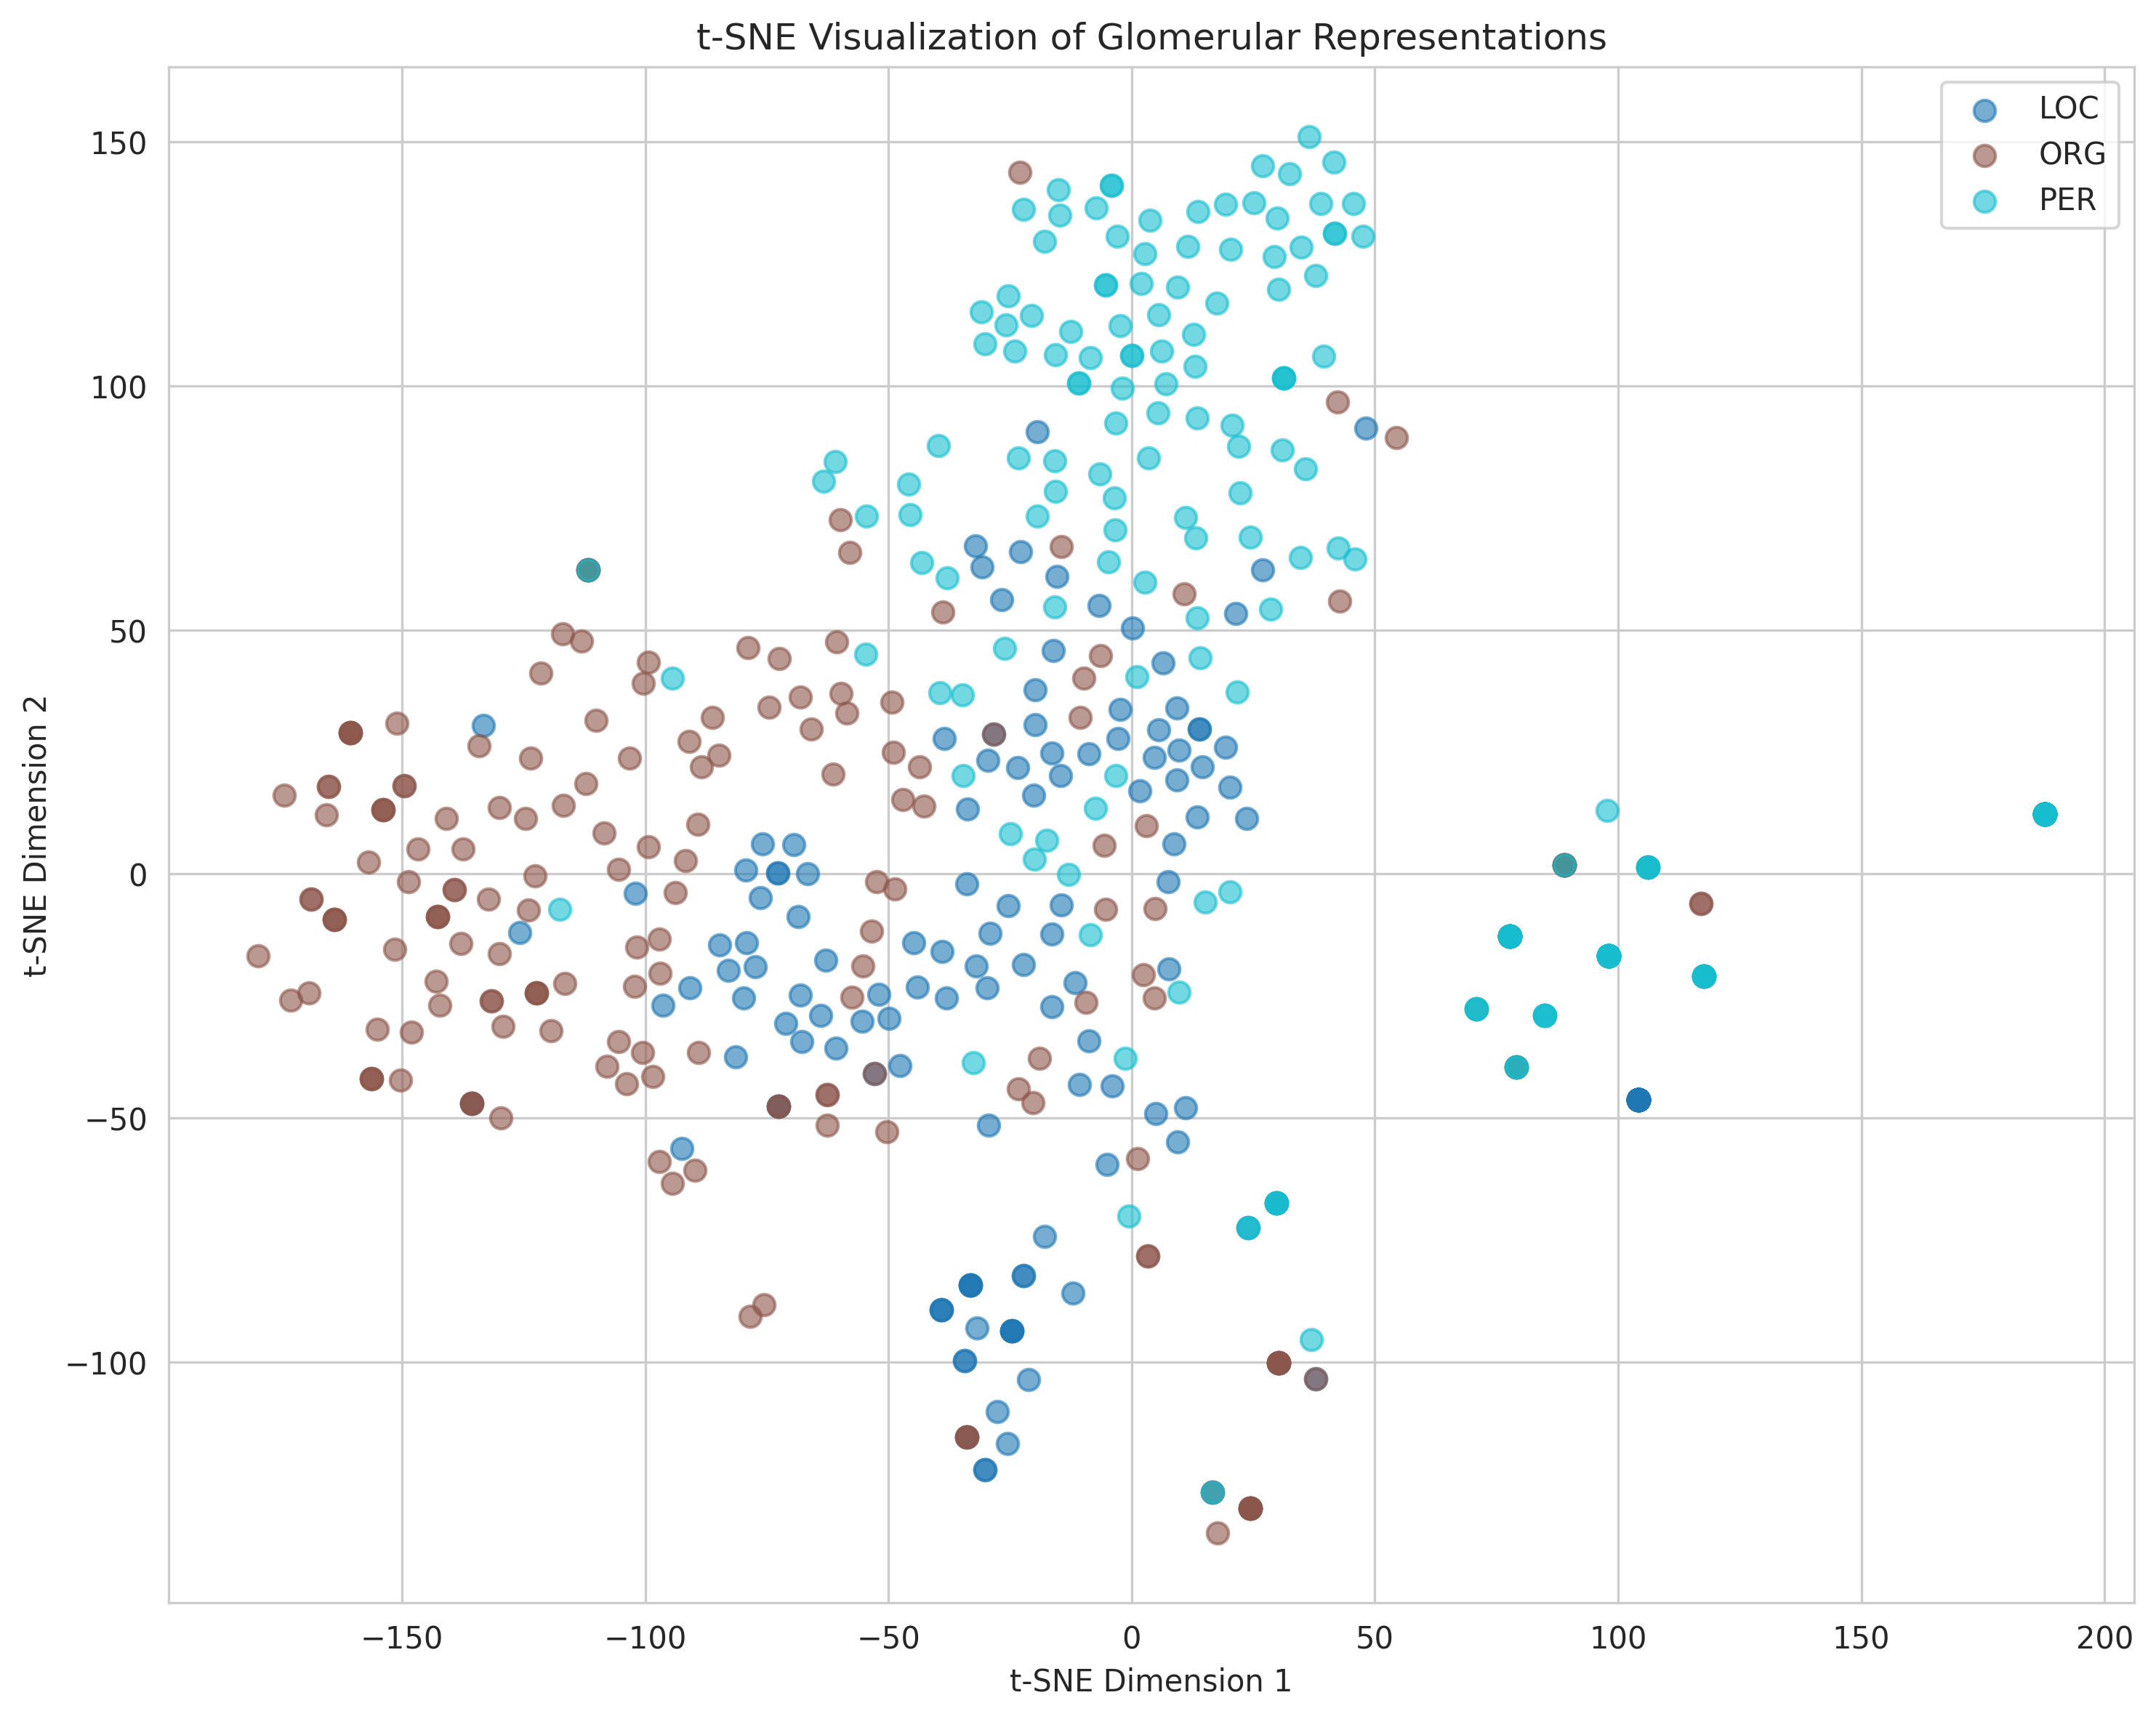


ACTIVATION_MISH


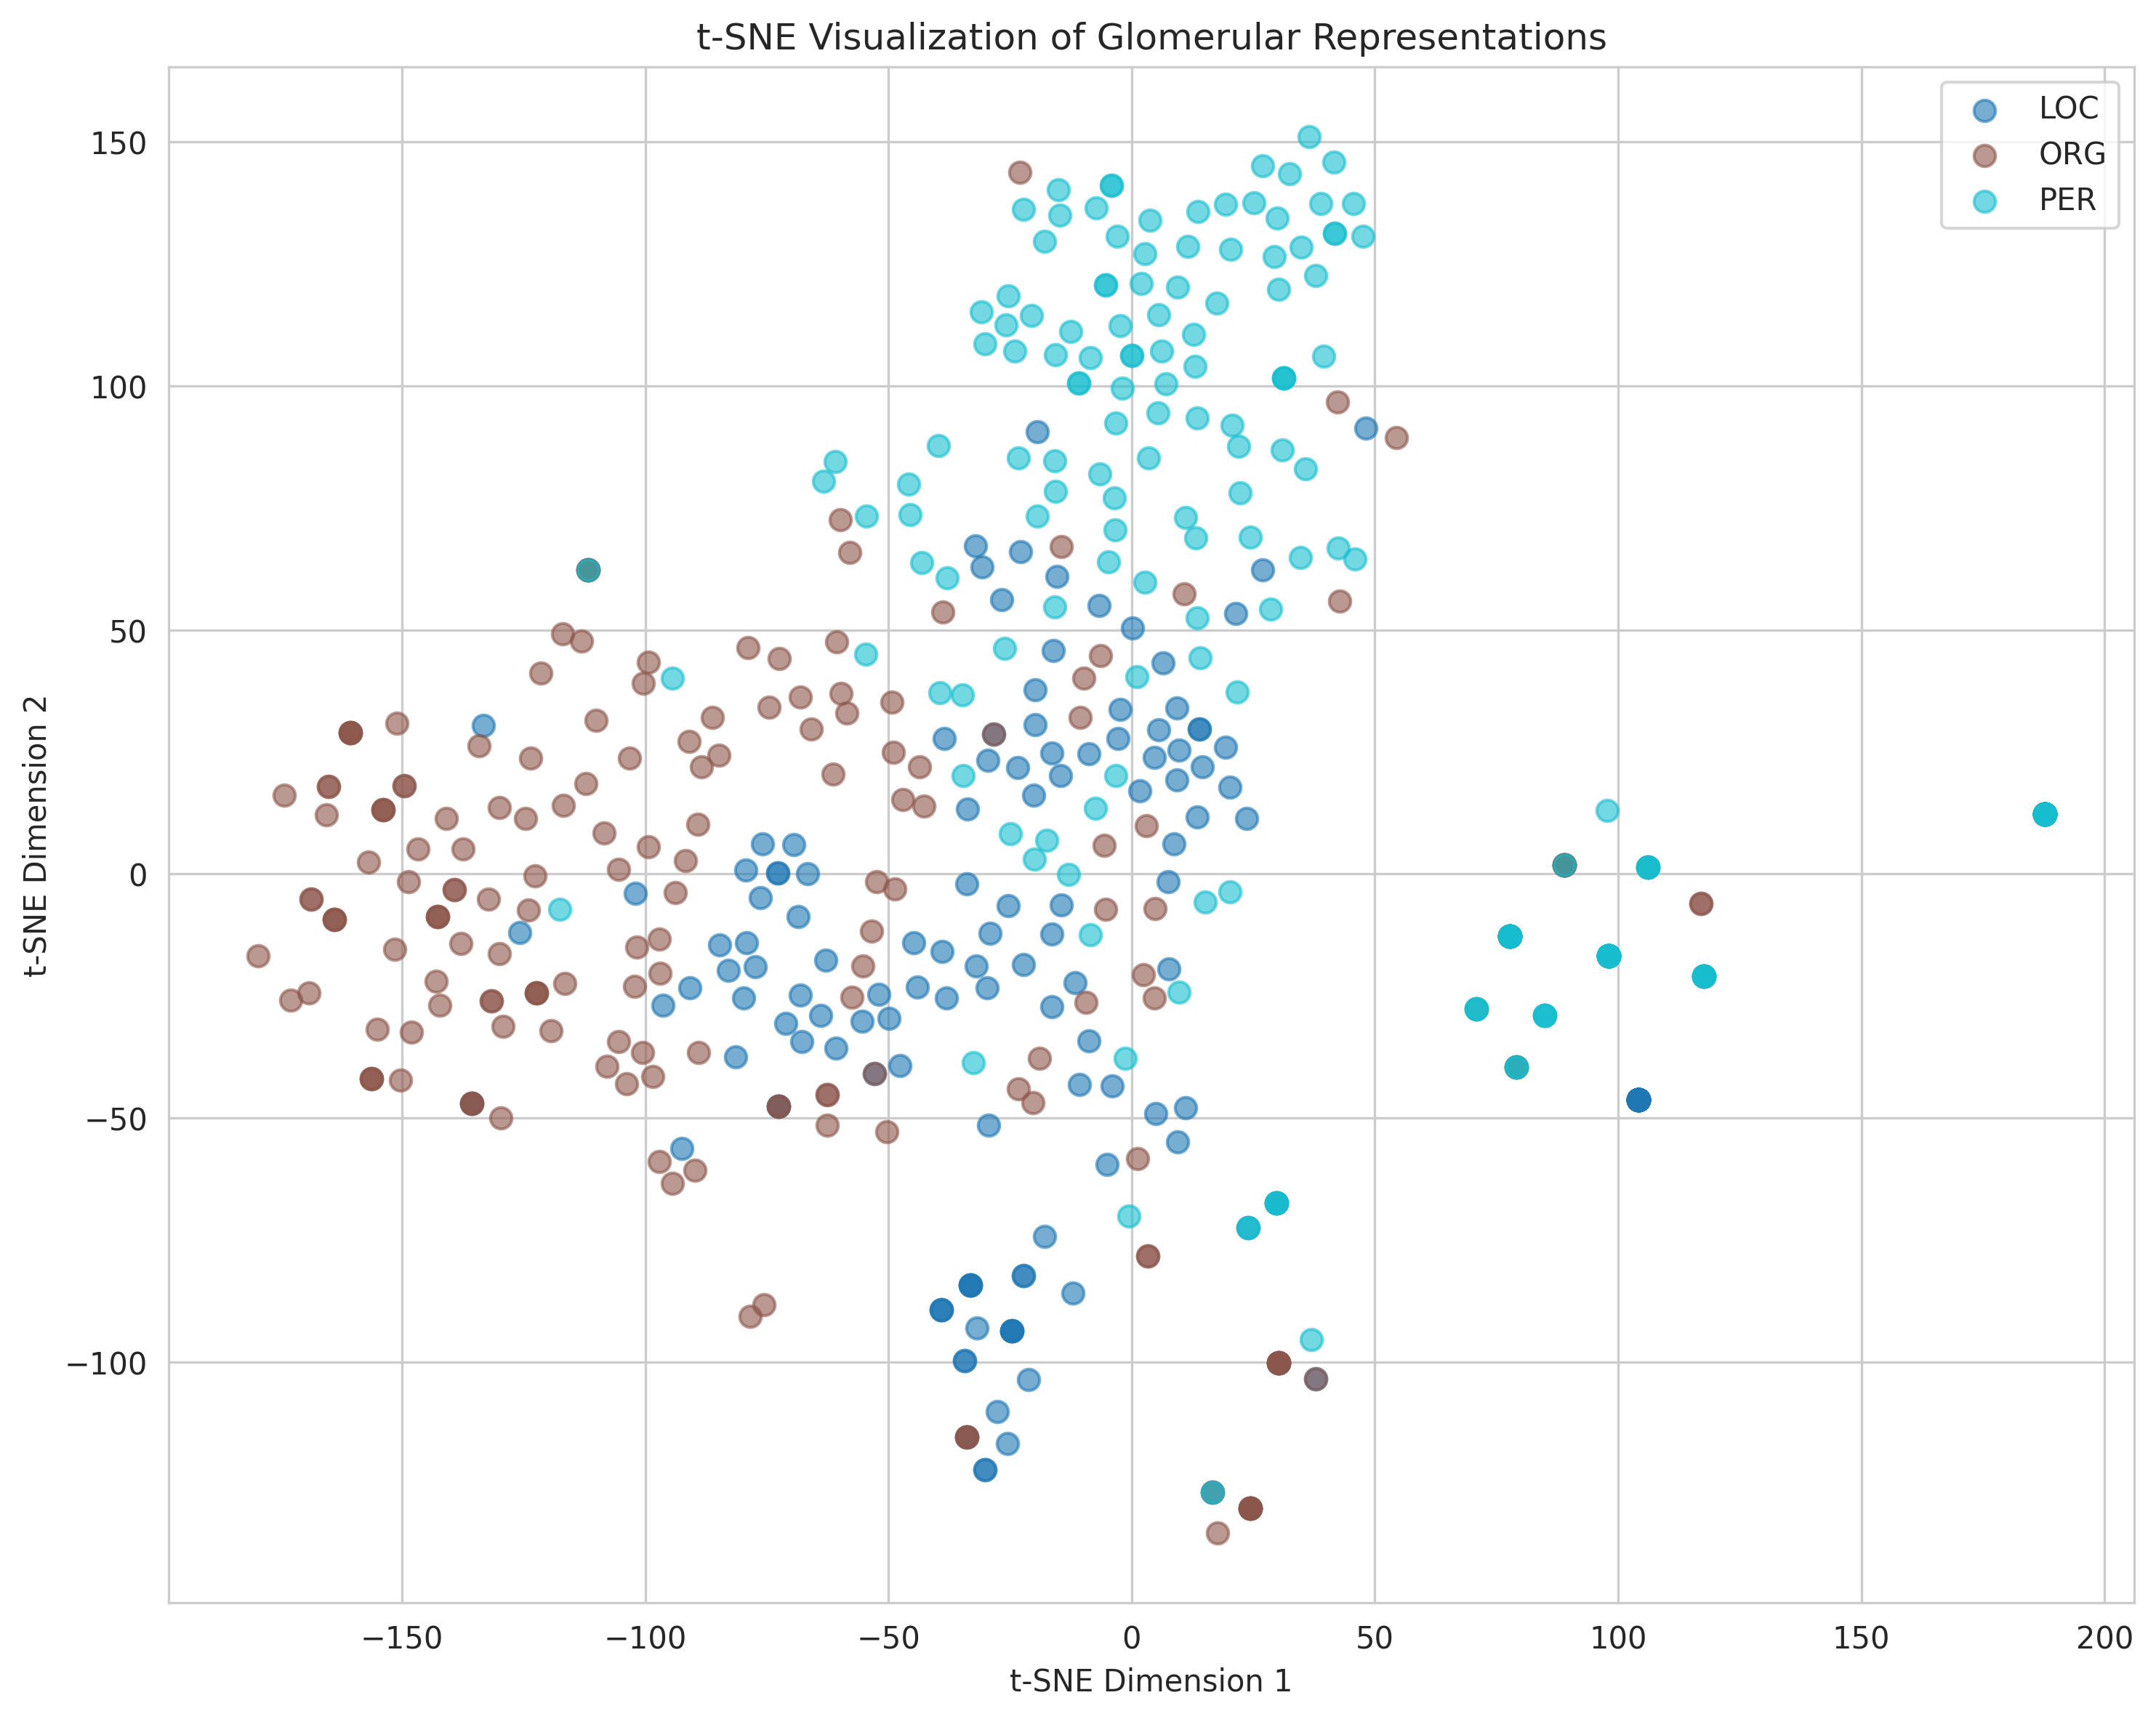


MORE_GLOMERULI


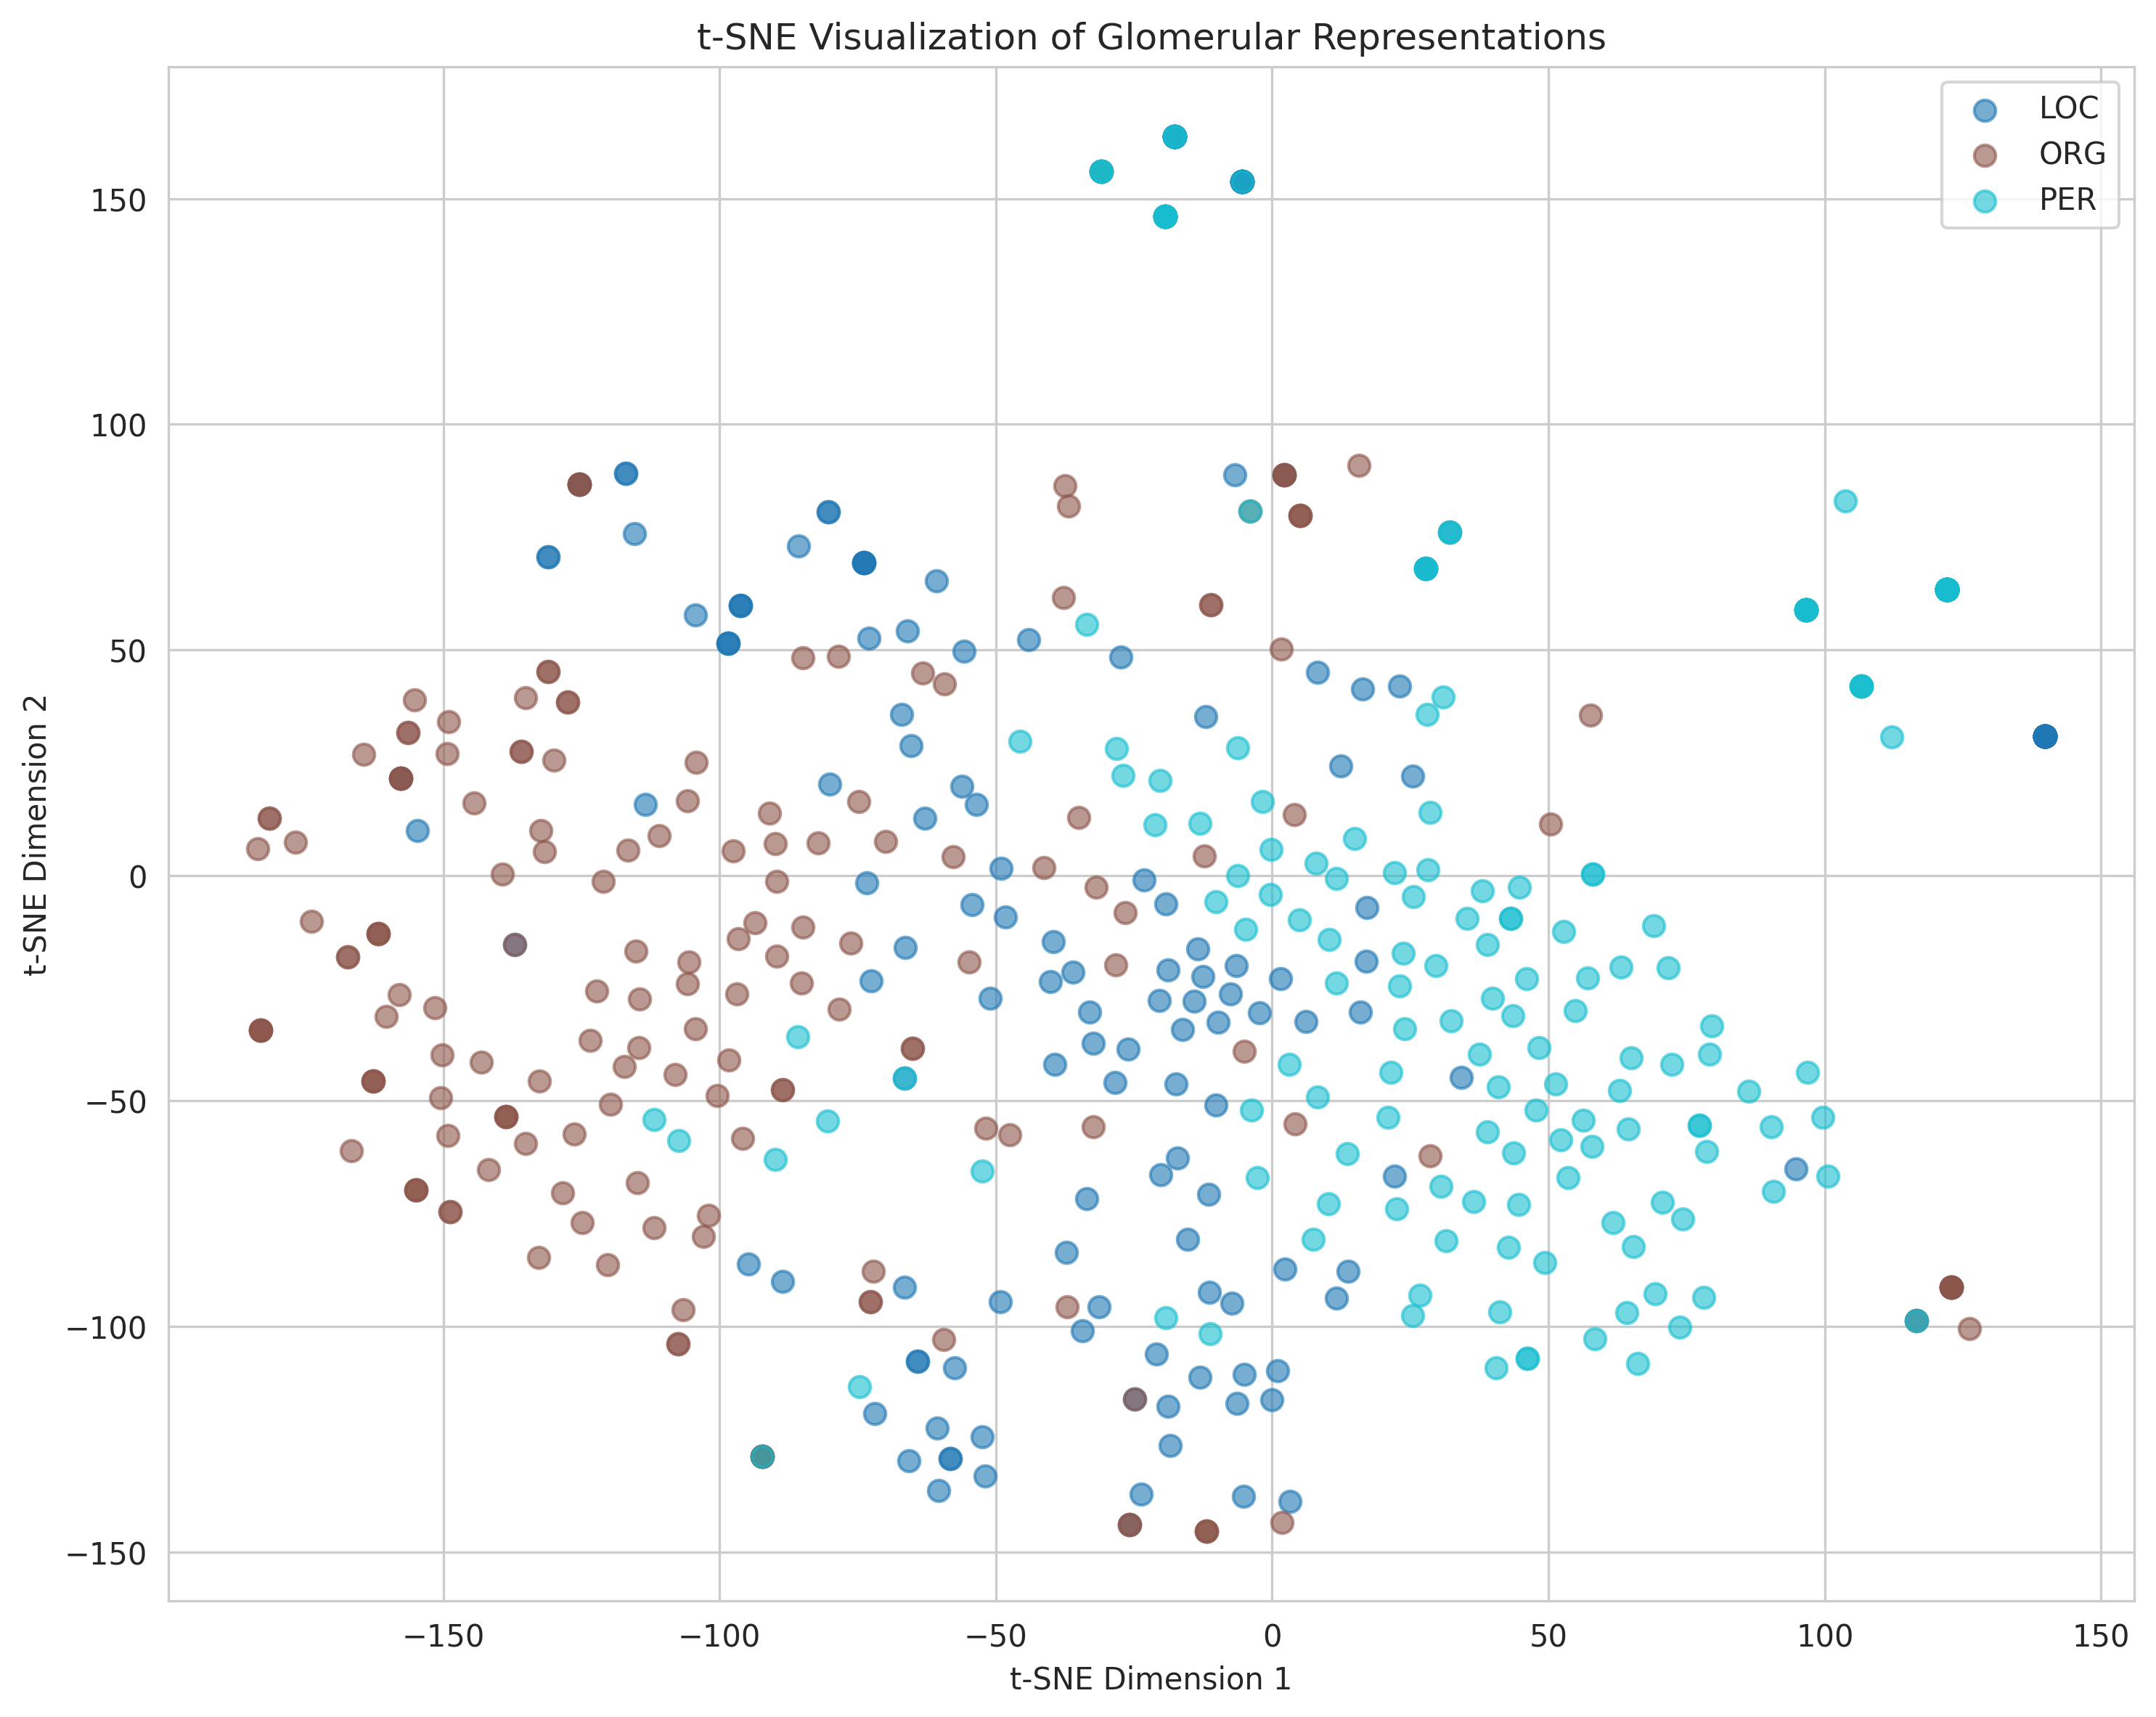


GELU_MORE_RECEPTORS


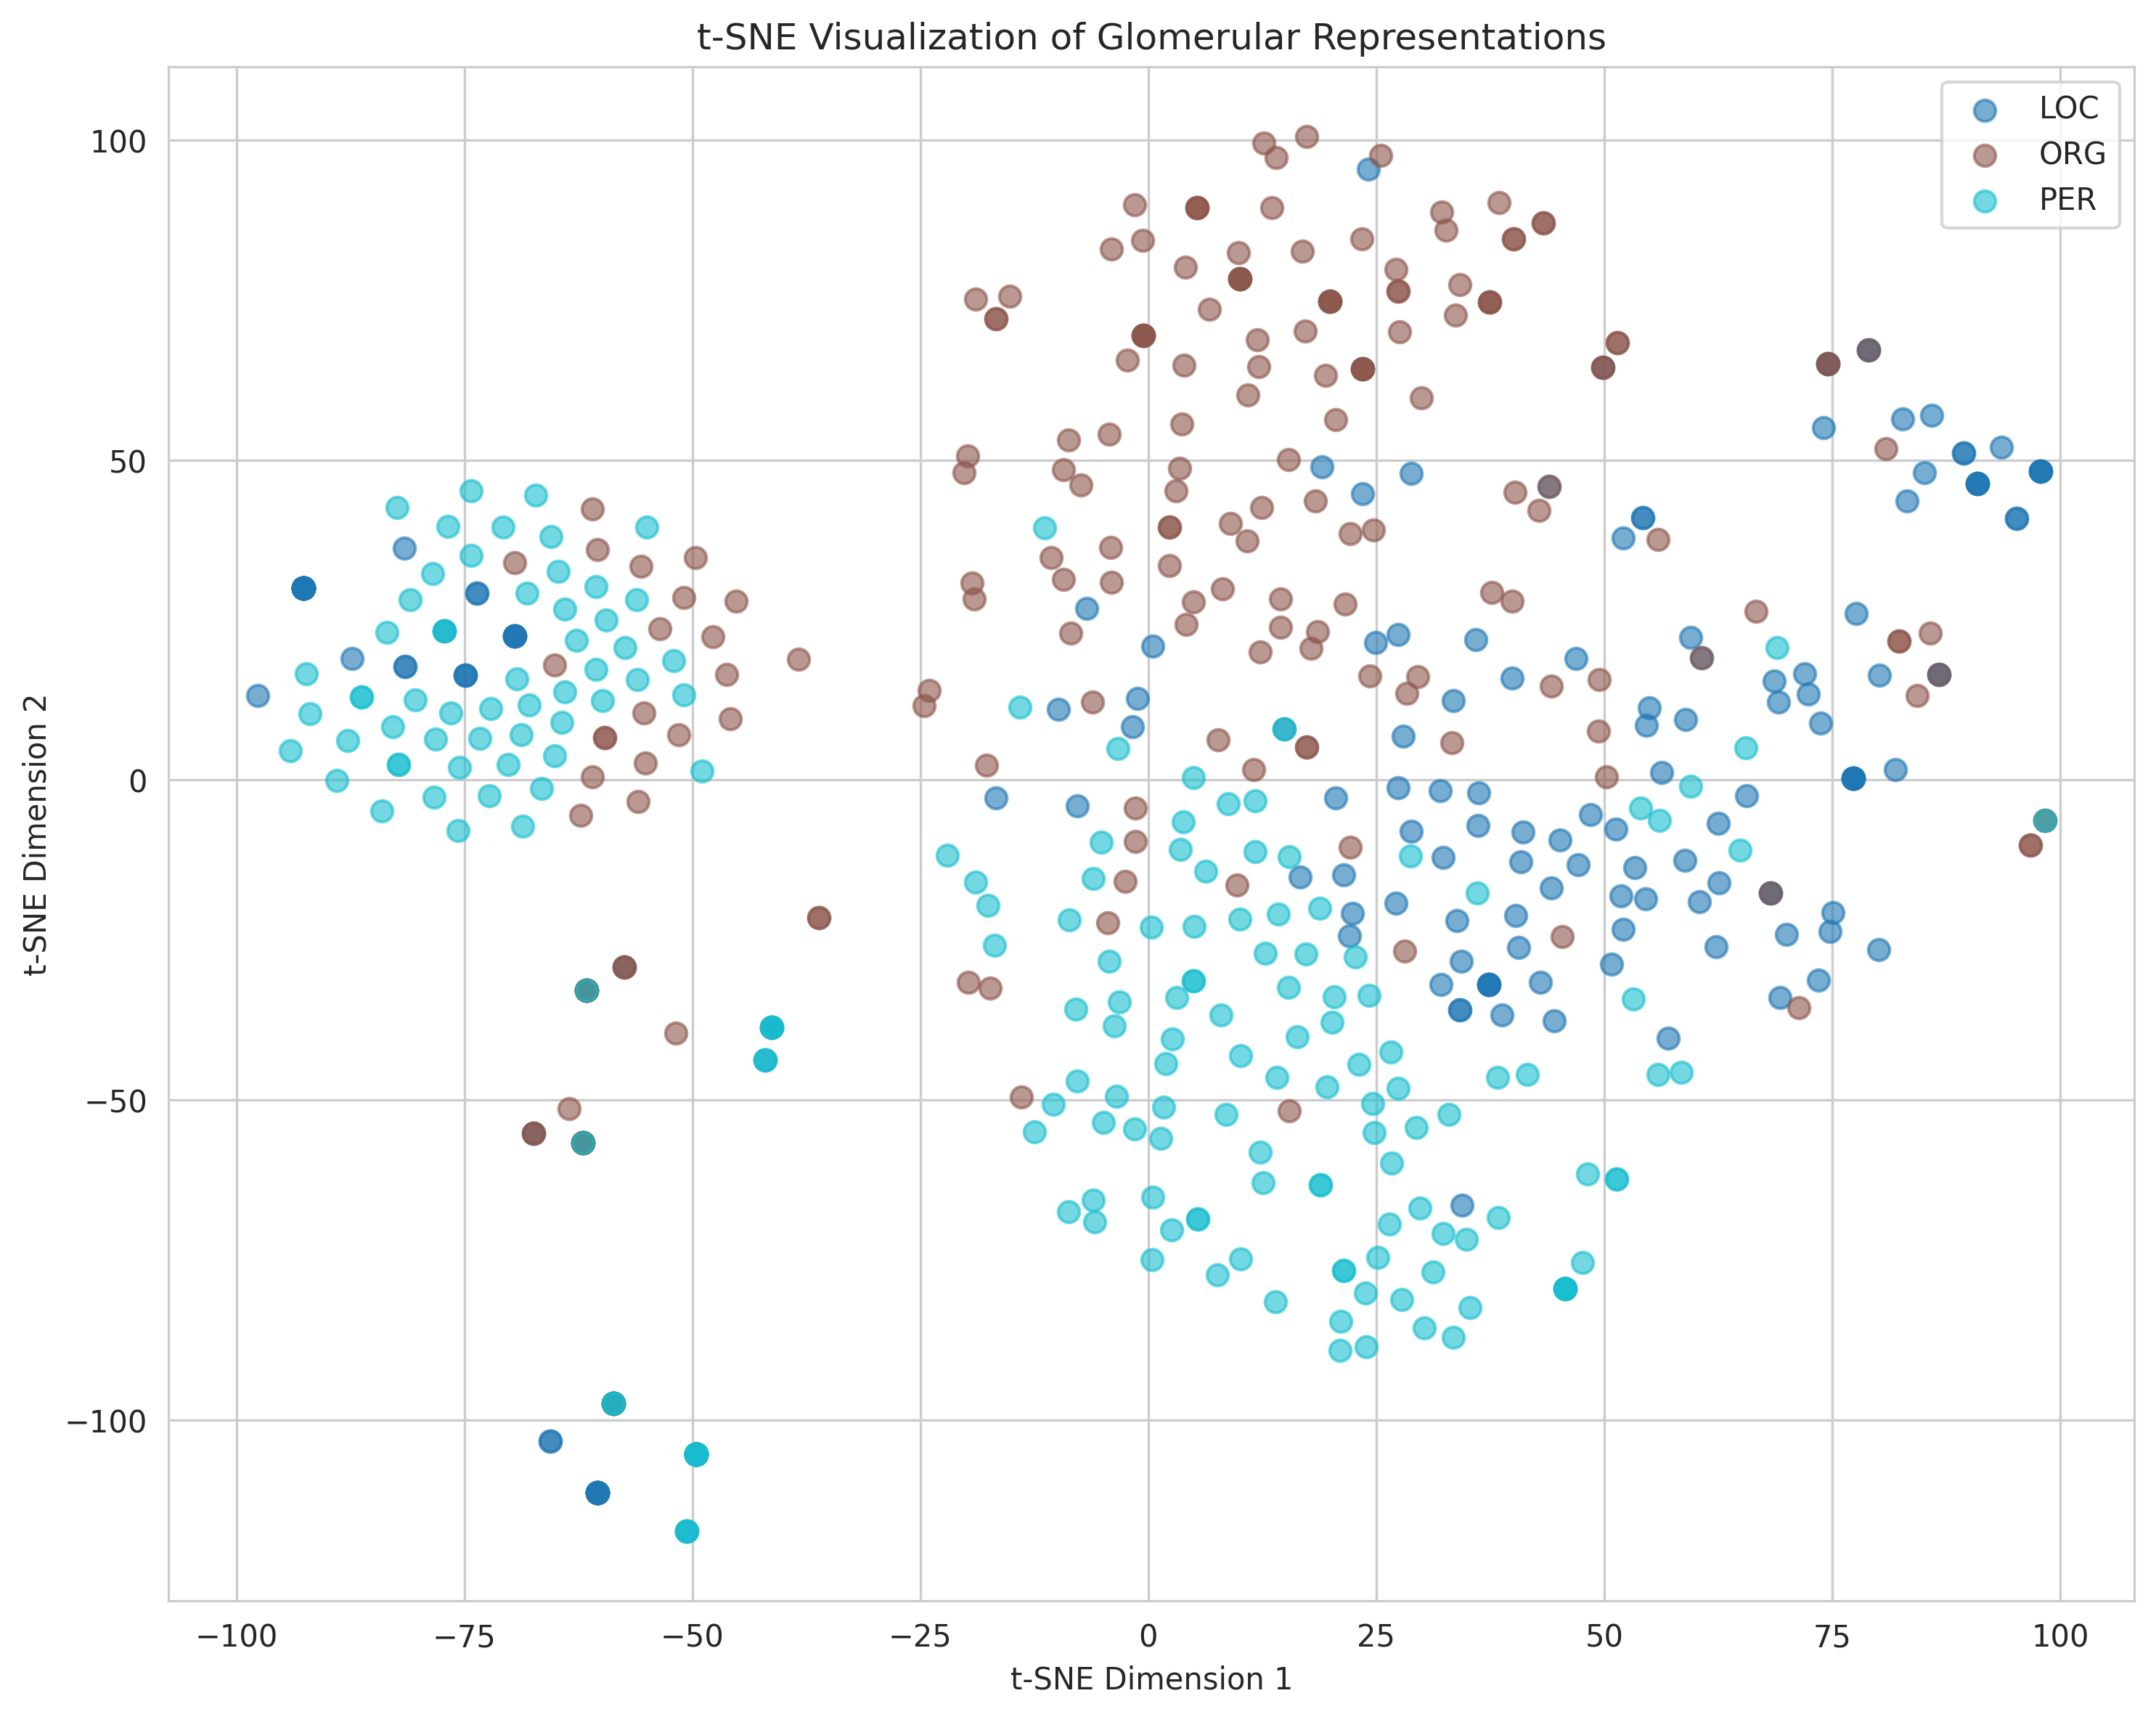

In [43]:
from IPython.display import Image, display

print("\n" + "="*80)
print("RECEPTOR ACTIVATION HEATMAPS")
print("="*80)

for exp_name, data in heatmap_results.items():
    heatmap_path = os.path.join(data['save_dir'], 'receptor_heatmap.png')
    
    if os.path.exists(heatmap_path):
        print(f"\n{'='*80}")
        print(f"{exp_name.upper()}")
        print(f"{'='*80}")
        display(Image(filename=heatmap_path))

print("\n" + "="*80)
print("t-SNE VISUALIZATIONS")
print("="*80)

for exp_name, data in heatmap_results.items():
    tsne_path = os.path.join(data['save_dir'], 'glomeruli_tsne.png')
    
    if os.path.exists(tsne_path):
        print(f"\n{'='*80}")
        print(f"{exp_name.upper()}")
        print(f"{'='*80}")
        display(Image(filename=tsne_path))

---
## 📊 Section 4: Comprehensive Metrics Analysis

### 4.1 Load All Experiment Results

In [45]:
import json
import pandas as pd
from pathlib import Path

# Load results from all experiments
all_experiments = [
    'activation_gelu',
    'activation_swish', 
    'activation_mish',
    'more_receptors',
    'more_glomeruli',
    'fewer_receptors',
    'strong_diversity',
    'very_strong_diversity',
    'gelu_more_receptors',
    'minimal_gelu',
    'baseline',
    'olfactory_full',
    'olfactory_no_glomeruli'
]

experiment_results = {}

for exp_name in all_experiments:
    results_path = f'results_marathi/{exp_name}/results.json'
    
    if os.path.exists(results_path):
        with open(results_path, 'r') as f:
            experiment_results[exp_name] = json.load(f)
        print(f"✓ Loaded results for: {exp_name}")
    else:
        print(f"⚠️  Results not found for: {exp_name}")

print(f"\n✓ Loaded results for {len(experiment_results)} experiments")

✓ Loaded results for: activation_gelu
⚠️  Results not found for: activation_swish
✓ Loaded results for: activation_mish
⚠️  Results not found for: more_receptors
✓ Loaded results for: more_glomeruli
⚠️  Results not found for: fewer_receptors
⚠️  Results not found for: strong_diversity
⚠️  Results not found for: very_strong_diversity
✓ Loaded results for: gelu_more_receptors
⚠️  Results not found for: minimal_gelu
✓ Loaded results for: baseline
⚠️  Results not found for: olfactory_full
⚠️  Results not found for: olfactory_no_glomeruli

✓ Loaded results for 5 experiments


### 4.2 Comprehensive Metrics Table

In [46]:
# Create comprehensive metrics table
metrics_data = []

for exp_name, results in experiment_results.items():
    test_metrics = results.get('test', {})
    per_entity = test_metrics.get('per_entity', {})
    
    # Extract metrics
    row = {
        'Experiment': exp_name,
        'F1': test_metrics.get('f1', 0),
        'Precision': test_metrics.get('precision', 0),
        'Recall': test_metrics.get('recall', 0),
        'LOC_F1': per_entity.get('LOC', 0),
        'MISC_F1': per_entity.get('MISC', 0),
        'ORG_F1': per_entity.get('ORG', 0),
        'PER_F1': per_entity.get('PER', 0),
        'Micro_Avg': per_entity.get('micro avg', test_metrics.get('f1', 0)),
        'Macro_Avg': per_entity.get('macro avg', 0),
        'Weighted_Avg': per_entity.get('weighted avg', 0)
    }
    
    metrics_data.append(row)

# Create DataFrame
metrics_df = pd.DataFrame(metrics_data)

# Sort by F1 score descending
metrics_df = metrics_df.sort_values('F1', ascending=False)

print("\n" + "="*120)
print("COMPREHENSIVE METRICS TABLE")
print("="*120)
print(metrics_df.to_string(index=False))
print("="*120)


COMPREHENSIVE METRICS TABLE
         Experiment       F1  Precision   Recall   LOC_F1  MISC_F1   ORG_F1   PER_F1  Micro_Avg  Macro_Avg  Weighted_Avg
gelu_more_receptors 0.807443   0.826159 0.789557 0.751938        0 0.822674 0.869681   0.807443   0.814764      0.807240
     more_glomeruli 0.802484   0.841877 0.766614 0.752844        0 0.786026 0.880420   0.802484   0.806430      0.800249
    activation_gelu 0.790093   0.811510 0.769778 0.744141        0 0.790765 0.852547   0.790093   0.795817      0.789729
    activation_mish 0.790093   0.811510 0.769778 0.744141        0 0.790765 0.852547   0.790093   0.795817      0.789729
           baseline 0.768980   0.794266 0.745253 0.722772        0 0.773296 0.829404   0.768980   0.775157      0.768957


### 4.3 Best Performing Models

In [47]:
# Show top 5 models
print("\n" + "="*80)
print("TOP 5 MODELS BY F1 SCORE")
print("="*80)

top5 = metrics_df.head(5)[['Experiment', 'F1', 'Precision', 'Recall', 'Micro_Avg', 'Macro_Avg']]
print(top5.to_string(index=False))

# Best per entity type
print("\n" + "="*80)
print("BEST MODEL PER ENTITY TYPE")
print("="*80)

entity_types = ['LOC_F1', 'MISC_F1', 'ORG_F1', 'PER_F1']
for entity in entity_types:
    best_idx = metrics_df[entity].idxmax()
    best_exp = metrics_df.loc[best_idx, 'Experiment']
    best_score = metrics_df.loc[best_idx, entity]
    entity_name = entity.replace('_F1', '')
    print(f"{entity_name:8} : {best_exp:30} (F1 = {best_score:.4f})")

print("="*80)


TOP 5 MODELS BY F1 SCORE
         Experiment       F1  Precision   Recall  Micro_Avg  Macro_Avg
gelu_more_receptors 0.807443   0.826159 0.789557   0.807443   0.814764
     more_glomeruli 0.802484   0.841877 0.766614   0.802484   0.806430
    activation_gelu 0.790093   0.811510 0.769778   0.790093   0.795817
    activation_mish 0.790093   0.811510 0.769778   0.790093   0.795817
           baseline 0.768980   0.794266 0.745253   0.768980   0.775157

BEST MODEL PER ENTITY TYPE
LOC      : more_glomeruli                 (F1 = 0.7528)
MISC     : gelu_more_receptors            (F1 = 0.0000)
ORG      : gelu_more_receptors            (F1 = 0.8227)
PER      : more_glomeruli                 (F1 = 0.8804)


### 4.4 Statistical Summary

In [48]:
# Statistical summary
print("\n" + "="*80)
print("STATISTICAL SUMMARY")
print("="*80)

summary_cols = ['F1', 'Precision', 'Recall', 'Macro_Avg', 'Micro_Avg']
summary_stats = metrics_df[summary_cols].describe()

print(summary_stats)
print("="*80)


STATISTICAL SUMMARY
             F1  Precision    Recall  Macro_Avg  Micro_Avg
count  5.000000   5.000000  5.000000   5.000000   5.000000
mean   0.791819   0.817064  0.768196   0.797597   0.791819
std    0.014878   0.017887  0.015734   0.014854   0.014878
min    0.768980   0.794266  0.745253   0.775157   0.768980
25%    0.790093   0.811510  0.766614   0.795817   0.790093
50%    0.790093   0.811510  0.769778   0.795817   0.790093
75%    0.802484   0.826159  0.769778   0.806430   0.802484
max    0.807443   0.841877  0.789557   0.814764   0.807443


---
## 📈 Section 5: Visualizations

### 5.1 Overall F1 Score Comparison

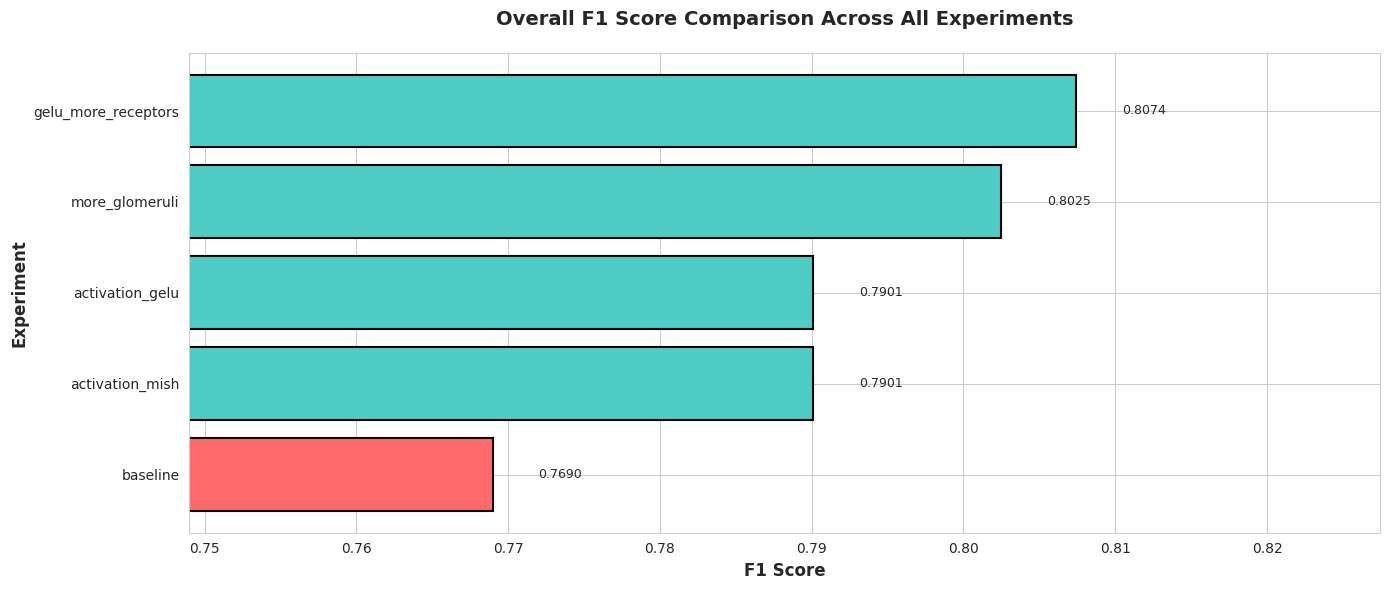

✓ Saved: visualizations_marathi/f1_comparison.png


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style('whitegrid')
plt.figure(figsize=(14, 6))

# Sort by F1
sorted_df = metrics_df.sort_values('F1', ascending=True)

# Create horizontal bar chart
# Changed condition slightly to handle case sensitivity better
colors = ['#FF6B6B' if 'baseline' in str(exp).lower() else '#4ECDC4' for exp in sorted_df['Experiment']]

plt.barh(sorted_df['Experiment'], sorted_df['F1'], color=colors, edgecolor='black', linewidth=1.5)
plt.xlabel('F1 Score', fontsize=12, fontweight='bold')
plt.ylabel('Experiment', fontsize=12, fontweight='bold')
plt.title('Overall F1 Score Comparison Across All Experiments', fontsize=14, fontweight='bold', pad=20)
plt.xlim([sorted_df['F1'].min() - 0.02, sorted_df['F1'].max() + 0.02])

# Add value labels
for i, (idx, row) in enumerate(sorted_df.iterrows()):
    plt.text(row['F1'] + 0.003, i, f"{row['F1']:.4f}", va='center', fontsize=9)

plt.tight_layout()

# FIX: Changed directory to visualizations_marathi
plt.savefig('visualizations_marathi/f1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: visualizations_marathi/f1_comparison.png")

### 5.2 Per-Entity Performance Comparison

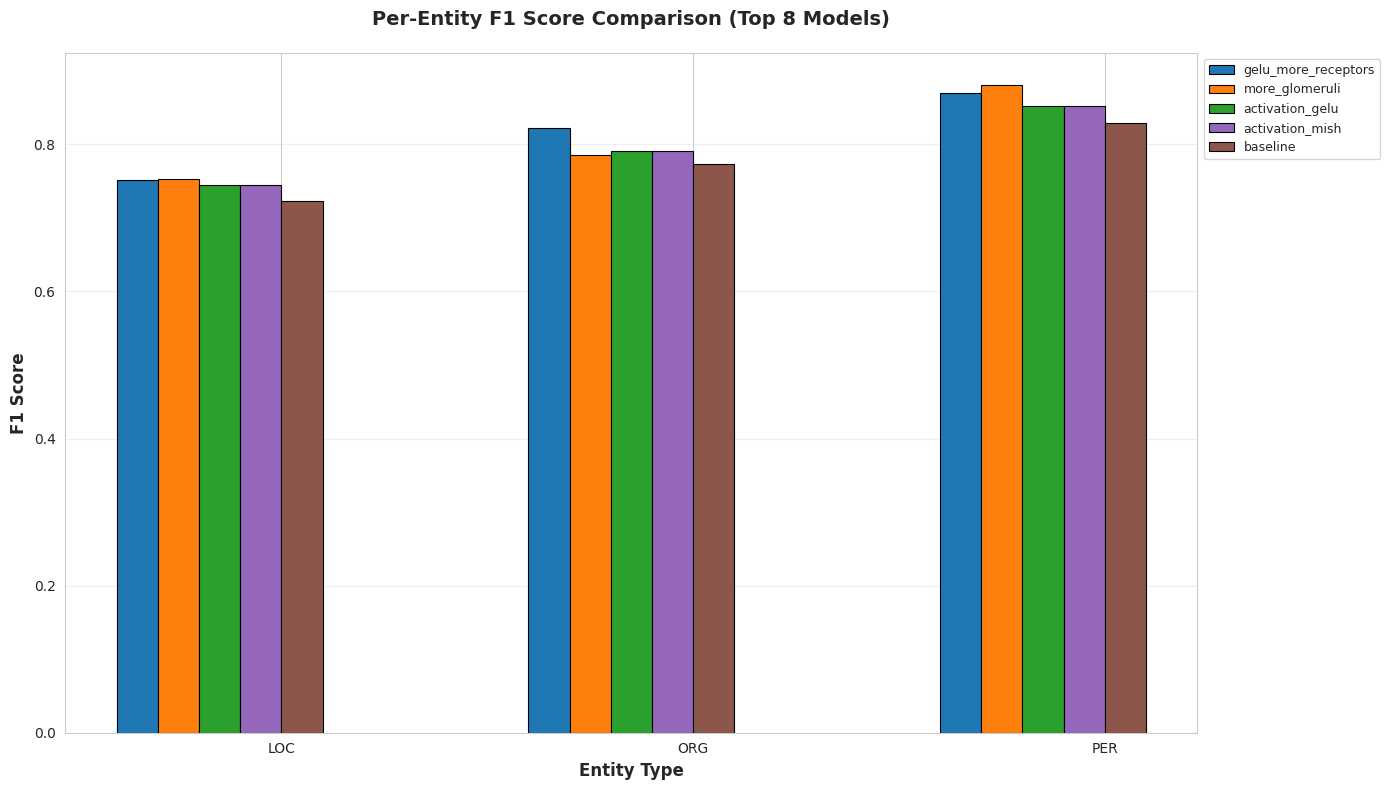

✓ Saved: visualizations_marathi/per_entity_comparison.png


In [62]:
import numpy as np
import os
import matplotlib.pyplot as plt

# Create directory if it doesn't exist
os.makedirs('visualizations_marathi', exist_ok=True)

# Per-entity comparison
fig, ax = plt.subplots(figsize=(14, 8))

# REMOVED MISC (only LOC, ORG, PER for Marathi)
entity_cols = ['LOC_F1', 'ORG_F1', 'PER_F1']
entity_names = ['LOC', 'ORG', 'PER']

# Take top 8 experiments by overall F1
top_experiments = metrics_df.head(8)

x = np.arange(len(entity_names))
width = 0.1

colors = plt.cm.tab10(np.linspace(0, 1, 8))

for i, (idx, row) in enumerate(top_experiments.iterrows()):
    scores = [row[col] for col in entity_cols]
    ax.bar(x + i * width, scores, width, label=row['Experiment'], color=colors[i], edgecolor='black', linewidth=0.8)

ax.set_xlabel('Entity Type', fontsize=12, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Entity F1 Score Comparison (Top 8 Models)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x + width * 3.5)
ax.set_xticklabels(entity_names)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# Fix: Save to visualizations_marathi
plt.savefig('visualizations_marathi/per_entity_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: visualizations_marathi/per_entity_comparison.png")

### 5.3 Precision vs Recall Scatter Plot

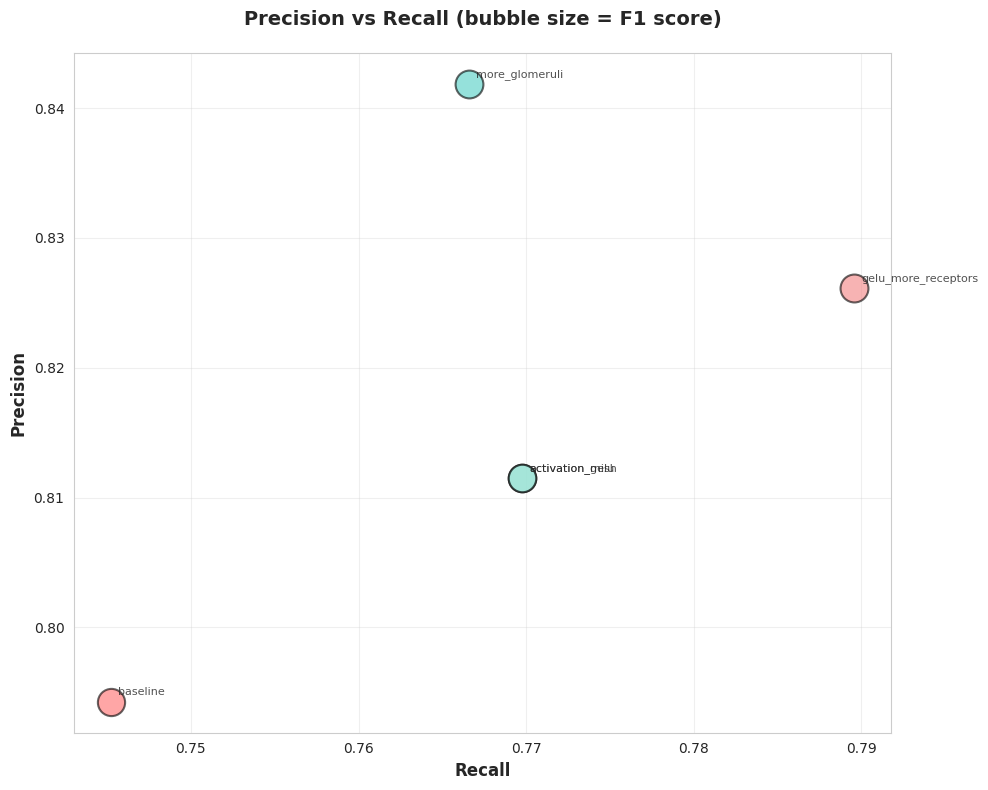

✓ Saved: visualizations_marathi/precision_recall_scatter.png


In [59]:
# Precision vs Recall
fig, ax = plt.subplots(figsize=(10, 8))

# Color by model type
colors_map = {
    'baseline': '#FF6B6B',
    'olfactory': '#4ECDC4',
    'activation': '#95E1D3',
    'receptors': '#F38181'
}

def get_color(exp_name):
    if 'baseline' in exp_name:
        return colors_map['baseline']
    elif 'activation' in exp_name:
        return colors_map['activation']
    elif 'receptor' in exp_name:
        return colors_map['receptors']
    else:
        return colors_map['olfactory']

for idx, row in metrics_df.iterrows():
    ax.scatter(row['Recall'], row['Precision'], 
              s=row['F1'] * 500,  # Size proportional to F1
              c=get_color(row['Experiment']),
              alpha=0.6,
              edgecolors='black',
              linewidth=1.5)
    
    # Add labels for top 5
    if idx in metrics_df.head(5).index:
        ax.annotate(row['Experiment'], 
                   (row['Recall'], row['Precision']),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=8, alpha=0.8)

ax.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax.set_title('Precision vs Recall (bubble size = F1 score)', fontsize=14, fontweight='bold', pad=20)
ax.grid(alpha=0.3)

plt.tight_layout()
# Fix: Save to visualizations_marathi
plt.savefig('visualizations_marathi/precision_recall_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: visualizations_marathi/precision_recall_scatter.png")

### 5.4 Micro vs Macro Average Comparison

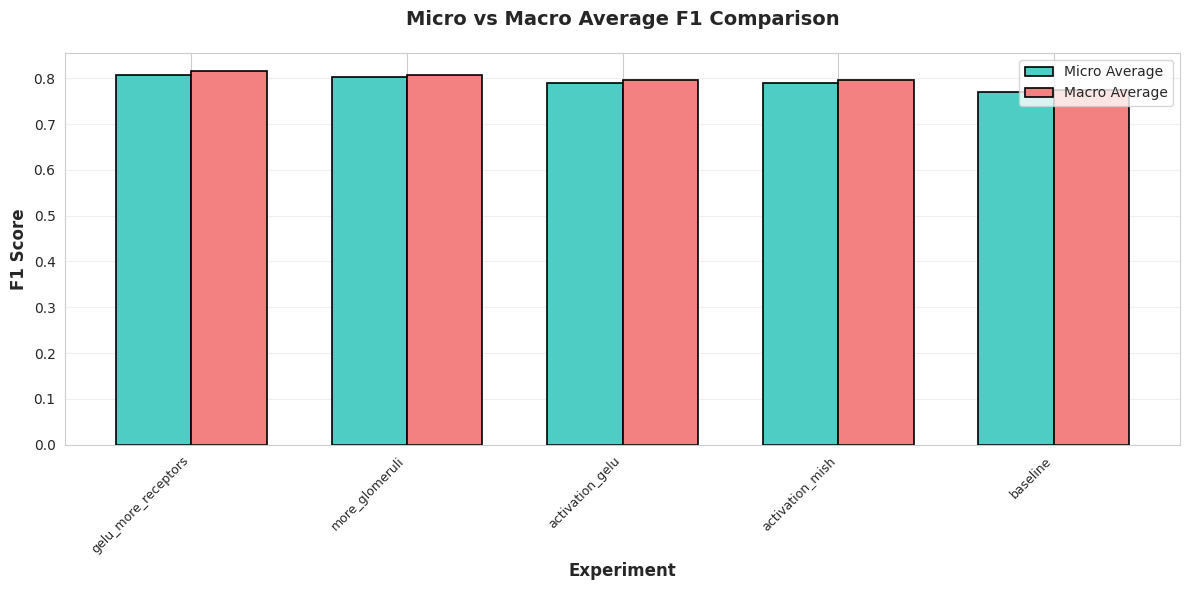

✓ Saved: visualizations_marathi/micro_macro_comparison.png


In [60]:
# Micro vs Macro
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics_df))
width = 0.35

ax.bar(x - width/2, metrics_df['Micro_Avg'], width, label='Micro Average', 
       color='#4ECDC4', edgecolor='black', linewidth=1.2)
ax.bar(x + width/2, metrics_df['Macro_Avg'], width, label='Macro Average',
       color='#F38181', edgecolor='black', linewidth=1.2)

ax.set_xlabel('Experiment', fontsize=12, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_title('Micro vs Macro Average F1 Comparison', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics_df['Experiment'], rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# Fix: Save to visualizations_marathi
plt.savefig('visualizations_marathi/micro_macro_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: visualizations_marathi/micro_macro_comparison.png")

---
## 💾 Section 6: Export Results

### 6.1 Save Comprehensive Results Summary

In [57]:
# Save metrics table as CSV
# Fix: exist_ok=True (not exit_ok)
os.makedirs('visualizations_marathi', exist_ok=True) 

# Fix: Split into two lines
metrics_df.to_csv('visualizations_marathi/comprehensive_metrics.csv', index=False)
print("✓ Saved: visualizations_marathi/comprehensive_metrics.csv")

# Save as JSON
summary_data = {
    'experiments': metrics_df.to_dict('records'),
    'best_overall': {
        'experiment': metrics_df.iloc[0]['Experiment'],
        'f1': float(metrics_df.iloc[0]['F1']),
        'precision': float(metrics_df.iloc[0]['Precision']),
        'recall': float(metrics_df.iloc[0]['Recall'])
    },
    'best_per_entity': {
        'LOC': {
            'experiment': metrics_df.loc[metrics_df['LOC_F1'].idxmax(), 'Experiment'],
            'f1': float(metrics_df['LOC_F1'].max())
        },
        # REMOVED 'MISC' SECTION HERE - Marathi dataset doesn't have it
        'ORG': {
            'experiment': metrics_df.loc[metrics_df['ORG_F1'].idxmax(), 'Experiment'],
            'f1': float(metrics_df['ORG_F1'].max())
        },
        'PER': {
            'experiment': metrics_df.loc[metrics_df['PER_F1'].idxmax(), 'Experiment'],
            'f1': float(metrics_df['PER_F1'].max())
        }
    },
    'statistics': {
        'mean_f1': float(metrics_df['F1'].mean()),
        'std_f1': float(metrics_df['F1'].std()),
        'min_f1': float(metrics_df['F1'].min()),
        'max_f1': float(metrics_df['F1'].max())
    }
}

with open('visualizations_marathi/comprehensive_summary.json', 'w') as f:
    json.dump(summary_data, f, indent=2)

print("✓ Saved: visualizations_marathi/comprehensive_summary.json")

✓ Saved: visualizations_marathi/comprehensive_metrics.csv
✓ Saved: visualizations_marathi/comprehensive_summary.json


### 6.2 Create Results Archive (for Download)

In [ ]:
# Create zip of all results and visualizations
!zip -r olfaction_ner_comprehensive_results.zip \
    results/ \
    visualizations/ \
    -x "results/*/checkpoints/*" \
    -x "*.git/*"

print("✓ Created archive: olfaction_ner_comprehensive_results.zip")

# For Google Colab - download
try:
    from google.colab import files
    files.download('olfaction_ner_comprehensive_results.zip')
    print("✓ Download started")
except ImportError:
    print("ℹ️  Not in Colab - archive saved locally")

### 6.3 Final Summary Report

In [54]:
print("\n" + "="*80)
print("FINAL SUMMARY REPORT")
print("="*80)

print(f"\n✅ Experiments Completed: {len(experiment_results)}/12")
print(f"✅ Heatmaps Generated: {len(heatmap_results)}")
print(f"✅ Visualizations Created: 5")

print("\n" + "-"*80)
print("BEST MODEL")
print("-"*80)
best_exp = metrics_df.iloc[0]
print(f"Experiment    : {best_exp['Experiment']}")
print(f"F1 Score      : {best_exp['F1']:.4f}")
print(f"Precision     : {best_exp['Precision']:.4f}")
print(f"Recall        : {best_exp['Recall']:.4f}")
print(f"Micro Average : {best_exp['Micro_Avg']:.4f}")
print(f"Macro Average : {best_exp['Macro_Avg']:.4f}")

print("\n" + "-"*80)
print("SAVED FILES")
print("-"*80)
print("📁 results/                  - All model checkpoints and training results")
print("📁 visualizations/           - All heatmaps and comparison charts")
print("📄 comprehensive_metrics.csv - Metrics table")
print("📄 comprehensive_summary.json - Summary statistics")
print("📦 olfaction_ner_comprehensive_results.zip - Complete archive")

print("\n" + "="*80)
print("ALL EXPERIMENTS COMPLETE! 🎉")
print("="*80)


FINAL SUMMARY REPORT

✅ Experiments Completed: 5/12
✅ Heatmaps Generated: 4
✅ Visualizations Created: 5

--------------------------------------------------------------------------------
BEST MODEL
--------------------------------------------------------------------------------
Experiment    : gelu_more_receptors
F1 Score      : 0.8074
Precision     : 0.8262
Recall        : 0.7896
Micro Average : 0.8074
Macro Average : 0.8148

--------------------------------------------------------------------------------
SAVED FILES
--------------------------------------------------------------------------------
📁 results/                  - All model checkpoints and training results
📁 visualizations/           - All heatmaps and comparison charts
📄 comprehensive_metrics.csv - Metrics table
📄 comprehensive_summary.json - Summary statistics
📦 olfaction_ner_comprehensive_results.zip - Complete archive

ALL EXPERIMENTS COMPLETE! 🎉


In [ ]:
import os
# Find the zip file
for root, dirs, files in os.walk('.'):
    for file in files:
        if file.endswith('olfaction_ner_comprehensive_results.zip'):
            print(f"Found at: {os.path.abspath(os.path.join(root, file))}")